# MySNCF Experience — Analyse exploratoire (EDA)

Objectif : comprendre ce que contiennent les sources (culture, tourisme, SNCF, transports urbains, vélo)
**avant** de construire quoi que ce soit dessus. Le notebook enchaîne le classique et le décalé.

| # | Partie | Question |
|---|--------|----------|
| 1 | Mise en place & téléchargement | Que dit le `.env` ? Qu'a-t-on sur disque ? |
| 2 | Inventaire & chargement robuste | Quels formats, quelles tailles, quels pièges d'encodage ? |
| 3 | Cartes d'identité des tables | Forme, valeurs manquantes, doublons, types sémantiques |
| 4 | Analyse univariée & bivariée | Distributions, catégories, corrélations, outliers, dates, **garde-fou temporel (rien après 2026)** |
| 5 | Géographie | Où sont les points ? Les coordonnées sont-elles fiables ? |
| 6 | **Cœur du projet : tourisme × gare** | À quelle distance d'une gare se trouve la culture ? |
| 7 | TGVmax | Disponibilité, rythme hebdo, réseau origine-destination |
| 8 | GTFS SNCF, horaires, accessibilité | Le pouls du réseau |
| 9 | Festivals, INSEE, fraîcheur | Temporalité des données |
| 10 | **Laboratoire** | Benford, arrondis, radar de clés de jointure, empreintes de schéma, Zipf, poésie des noms, PCA de départements |
| 11 | **Conclusion graphique** | 3 graphiques clés et un indicateur global (IAF) |

*Règle de lecture :* chaque section est indépendante ; si une source n'est pas dans `SOURCES`, la section correspondante l'indique et passe son tour.

## 1. Mise en place & téléchargement

In [39]:
import os, re, sys, math, zipfile, unicodedata, warnings
import xml.etree.ElementTree as ET
from collections import Counter, defaultdict
from itertools import combinations
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

warnings.filterwarnings("ignore")

# Racine du projet : on remonte jusqu'au dossier qui contient lib/
ROOT = Path.cwd().resolve()
while not (ROOT / "lib").is_dir():
    if ROOT.parent == ROOT:
        raise RuntimeError("Racine du projet introuvable (dossier lib/ absent)")
    ROOT = ROOT.parent
os.chdir(ROOT)                      # load_dotenv() et DATA_DIR sont relatifs à la racine
sys.path.insert(0, str(ROOT))

from dotenv import load_dotenv
from lib.downloader import download

load_dotenv()
DATA_DIR = ROOT / os.environ.get("DATA_DIR", "data")

sns.set_theme(style="whitegrid", context="notebook", palette="deep")
plt.rcParams.update({"figure.dpi": 110, "axes.titleweight": "bold", "axes.titlesize": 12})
pd.set_option("display.max_columns", 60, "display.max_colwidth", 70, "display.width", 200)
print("Racine :", ROOT, "\nDonnées :", DATA_DIR)

Racine : /Users/damienmolinieres/Documents/GitHub/MySNCF-Experience 
Données : /Users/damienmolinieres/Documents/GitHub/MySNCF-Experience/data


In [40]:
# ── Configuration ───────────────────────────────────────────────────────────
# Toutes les sources déclarées dans le .env (DATASET_<NOM>_URL → <nom>)
ALL_SOURCES = sorted(k[len("DATASET_"):-len("_URL")].lower()
                     for k in os.environ if k.startswith("DATASET_") and k.endswith("_URL"))

# Sources lourdes : à n'ajouter qu'en connaissance de cause
HEAVY = {"datatourisme_nt"} | {s for s in ALL_SOURCES if s.startswith("datatourisme_20")} | {"idfm"}

# Sélection de travail (cœur culture / tourisme / gares). Pour tout prendre :
#   SOURCES = [s for s in ALL_SOURCES if s not in HEAVY]
SOURCES = [
    "gares_voyageurs", "horaires_gares", "pieton_accessibilite_gares",
    "tgvmax", "lignes_par_region", "horaires_sncf_gtfs",
    "basilic", "datatourisme_place", "datatourisme_fma", "qualite_tourisme", "epv", "festivals",
    "cartographie_des_donnees_touristiques", "insee_tour_cap",
    "velo_stationnement_gares_centre_val_de_loire", "vls_paris_velib",
]

# Périmètre temporel : on est en octobre 2026, rien après fin 2026 (prévisions de planning comprises)
REF_DATE = pd.Timestamp("2026-10-06")
HORIZON_FIN = pd.Timestamp("2026-12-31")

FORCE_DOWNLOAD = False      # True → retélécharge même si le dossier existe
MAX_ROWS = 500_000          # au-delà (~x1,5) on échantillonne aléatoirement à la lecture
SEED = 42
RNG = np.random.default_rng(SEED)

print(f"{len(ALL_SOURCES)} sources dans le .env — {len(SOURCES)} retenues, {len(HEAVY)} marquées lourdes")

99 sources dans le .env — 16 retenues, 34 marquées lourdes


In [41]:
def has_data(source):
    d = DATA_DIR / source
    return d.is_dir() and any(p.is_file() and p.name != ".gitkeep" for p in d.rglob("*"))

a_telecharger = [s for s in SOURCES if FORCE_DOWNLOAD or not has_data(s)]
print("Déjà sur disque :", [s for s in SOURCES if s not in a_telecharger])
print("À télécharger   :", a_telecharger)

echecs = {}
for s in a_telecharger:
    try:
        download([s])
        print("  ✓", s)
    except Exception as e:                     # on continue : une source en erreur ne bloque pas l'EDA
        echecs[s] = f"{type(e).__name__}: {str(e)[:120]}"
        print("  ✗", s, "→", echecs[s])

Déjà sur disque : ['gares_voyageurs', 'horaires_gares', 'pieton_accessibilite_gares', 'tgvmax', 'lignes_par_region', 'horaires_sncf_gtfs', 'basilic', 'datatourisme_place', 'datatourisme_fma', 'qualite_tourisme', 'epv', 'festivals', 'cartographie_des_donnees_touristiques', 'insee_tour_cap', 'velo_stationnement_gares_centre_val_de_loire', 'vls_paris_velib']
À télécharger   : []


## 2. Inventaire & chargement robuste

,source,fichiers,taille_Mo,formats
0,datatourisme_place,1,272.65,.csv
1,insee_tour_cap,2,133.03,.csv
2,horaires_sncf_gtfs,8,100.46,.txt
3,datatourisme_fma,1,58.62,.csv
4,basilic,1,49.04,.csv
5,tgvmax,1,33.41,.csv
6,lignes_par_region,1,20.99,.csv
7,pieton_accessibilite_gares,1,16.14,.xml
8,festivals,1,2.59,.csv
9,qualite_tourisme,1,1.25,.csv


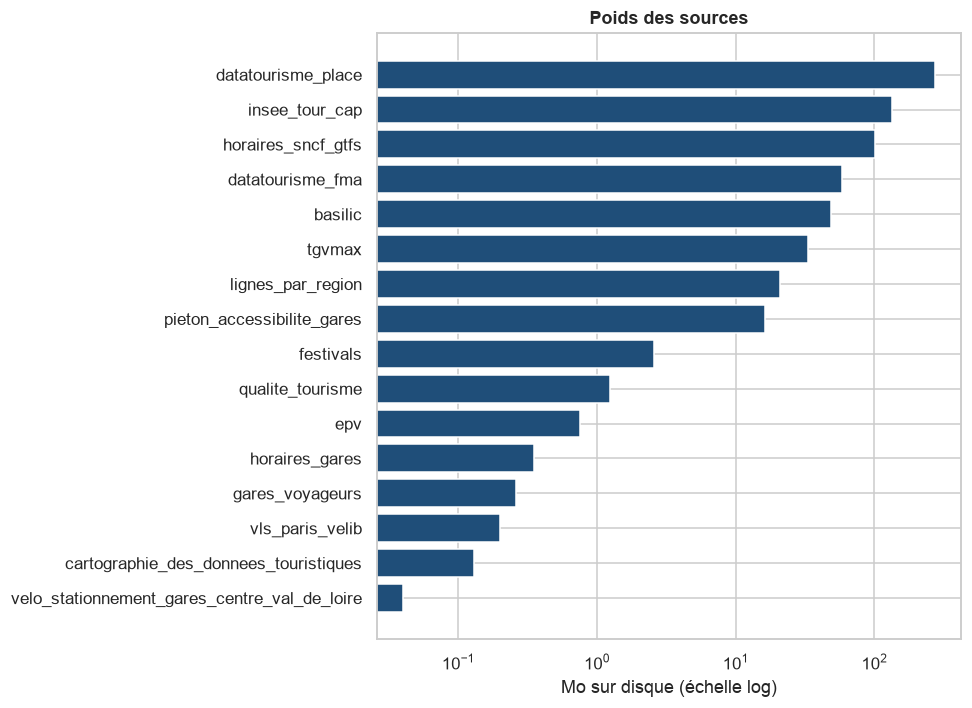

In [42]:
rows = []
for s in SOURCES:
    files = [p for p in (DATA_DIR / s).rglob("*") if p.is_file()] if (DATA_DIR / s).is_dir() else []
    rows.append(dict(source=s, fichiers=len(files),
                     taille_Mo=round(sum(p.stat().st_size for p in files) / 1e6, 2),
                     formats=", ".join(sorted({p.suffix.lower() or "(aucun)" for p in files}))))
INVENTAIRE = pd.DataFrame(rows).sort_values("taille_Mo", ascending=False).reset_index(drop=True)
display(INVENTAIRE)

fig, ax = plt.subplots(figsize=(9, 0.35 * len(INVENTAIRE) + 1))
ax.barh(INVENTAIRE.source[::-1], INVENTAIRE.taille_Mo[::-1].clip(lower=0.01), color="#1f4e79")
ax.set_xscale("log"); ax.set_xlabel("Mo sur disque (échelle log)"); ax.set_title("Poids des sources")
plt.tight_layout(); plt.show()

In [43]:
TABULAR = {".csv", ".txt", ".tsv", ".parquet"}


def _clean_cols(df):
    df.columns = [str(c).replace("﻿", "").strip() for c in df.columns]
    return df


def read_table(path, max_rows=MAX_ROWS):
    """Lit un CSV/TXT/Parquet de façon tolérante.

    Retourne (df, nb_lignes_total_approx, echantillonne). Encodage UTF-8 (BOM toléré, même doublé),
    repli latin-1 ; séparateur deviné sur l'en-tête ; repli moteur python si lignes irrégulières.
    """
    if path.suffix.lower() == ".parquet":
        df = pd.read_parquet(path)
        total = len(df)
        if total > max_rows:
            df = df.sample(max_rows, random_state=SEED)
        return _clean_cols(df), total, total > max_rows

    with open(path, "rb") as f:
        head = f.read(65536).decode("utf-8-sig", errors="replace").replace("﻿", "")
    first = head.splitlines()[0] if head else ""
    sep = max(",;\t|", key=first.count)
    with open(path, "rb") as f:
        total = sum(1 for _ in f) - 1

    sampled = total > 1.5 * max_rows
    frac = max_rows / total if sampled else 1.0
    skip = (lambda i: i > 0 and RNG.random() > frac) if sampled else None

    for enc in ("utf-8-sig", "latin-1"):
        for kw in ({"low_memory": False}, {"engine": "python", "on_bad_lines": "skip"}):
            try:
                df = pd.read_csv(path, sep=sep, encoding=enc, skiprows=skip,
                                 nrows=None if sampled else max_rows, **kw)
                return _clean_cols(df), total, sampled or total > max_rows
            except UnicodeDecodeError:
                break                                  # on passe à l'encodage suivant
            except Exception:
                continue
    raise ValueError(f"illisible : {path.name}")


DF, CATALOGUE, ILLISIBLES = {}, [], {}
for s in SOURCES:
    d = DATA_DIR / s
    for p in sorted(d.rglob("*")) if d.is_dir() else []:
        if p.suffix.lower() not in TABULAR or not p.is_file():
            continue
        key = f"{s}/{p.stem}"
        try:
            df, total, sampled = read_table(p)
        except Exception as e:
            ILLISIBLES[key] = str(e)[:100]
            continue
        if df.shape[0] == 0 or df.shape[1] < 2:        # fichiers vides (ex. transfers.txt) ou non tabulaires
            ILLISIBLES[key] = f"vide ou non tabulaire ({df.shape})"
            continue
        DF[key] = df
        CATALOGUE.append(dict(table=key, lignes_total_approx=total, lignes_chargees=len(df),
                              colonnes=df.shape[1], echantillon=sampled))

CATALOGUE = pd.DataFrame(CATALOGUE).set_index("table")
display(CATALOGUE)
if ILLISIBLES:
    print("Ignorées :", ILLISIBLES)

,lignes_total_approx,lignes_chargees,colonnes,echantillon
table,,,,
gares_voyageurs/gares-de-voyageurs,2792,2792,7,False
horaires_gares/horaires-des-gares1,6517,6517,5,False
tgvmax/tgvmax,358868,358868,11,False
lignes_par_region/lignes-par-region-administrative,2909,2909,19,False
horaires_sncf_gtfs/agency,8,8,5,False
horaires_sncf_gtfs/calendar_dates,235213,235213,3,False
horaires_sncf_gtfs/feed_info,1,1,9,False
horaires_sncf_gtfs/routes,744,744,9,False
horaires_sncf_gtfs/stop_times,525792,500000,9,True


Ignorées : {'horaires_sncf_gtfs/transfers': 'vide ou non tabulaire ((0, 6))'}


In [44]:
def find(fragment):
    """Première table dont le nom contient `fragment` (None si absente)."""
    for k in DF:
        if fragment in k:
            return DF[k]
    return None


def norm(x):
    """Minuscules, sans accents ni ponctuation : clé de comparaison de noms."""
    x = unicodedata.normalize("NFKD", str(x)).encode("ascii", "ignore").decode()
    return re.sub(r"[^a-z0-9]+", " ", x.lower()).strip()


def absent(*fragments):
    manquantes = [f for f in fragments if find(f) is None]
    if manquantes:
        print("⚠ Table(s) absente(s) :", manquantes, "→ ajouter la source dans SOURCES puis relancer.")
    return bool(manquantes)

## 3. Cartes d'identité des tables

Pour chaque colonne on déduit un **type sémantique** (identifiant, code, coordonnée, date, catégorie, texte, numérique).
C'est le garde-fou classique : une colonne `int64` n'est pas forcément une quantité — un code postal ou un SIRET ne se moyenne pas.

In [45]:
RE_CODE = re.compile(r"(^|[^a-z])(id|uic|insee|siret|siren|naf|iris|code|cp|rang|ident|uri|trigramme|numero|headsign|identifiant|docid|ligne|no|n)([^a-z]|$)", re.I)
RE_DATE_NAME = re.compile(r"date|time|maj|mise.?a.?jour|actualisation|creation|cr[ée]ation|period", re.I)
RE_DATE_VAL = re.compile(r"^\d{4}-\d{2}-\d{2}|^\d{2}/\d{2}/\d{4}|^\d{8}$")


def semantic_type(s):
    name = s.name if isinstance(s.name, str) else str(s.name)
    nn = s.dropna()
    if nn.empty:
        return "vide"
    if re.search(r"lat(itude)?$|^y_.*wgs|^stop_lat", name, re.I):
        return "latitude"
    if re.search(r"lon(gitude)?$|^x_.*wgs|^stop_lon", name, re.I):
        return "longitude"
    if pd.api.types.is_datetime64_any_dtype(s):
        return "date"
    if s.dtype == object:
        sample = nn.astype(str).head(200)
        if RE_DATE_NAME.search(name) and sample.str.match(RE_DATE_VAL).mean() > 0.8:
            return "date"
        if sample.str.len().mean() > 60:
            return "texte"
    if RE_CODE.search(name):
        return "code"
    if s.dtype == bool:
        return "booléen"
    if pd.api.types.is_numeric_dtype(s):
        return "catégorie" if nn.nunique() <= 20 else "numérique"
    return "catégorie" if nn.nunique() / len(nn) < 0.05 or nn.nunique() <= 50 else "texte/libre"


def entropy_bits(s):
    p = s.astype(str).value_counts(normalize=True)
    return float(-(p * np.log2(p)).sum())


def profile(df, sample=None):
    d = df.sample(min(sample, len(df)), random_state=SEED) if sample else df
    out = []
    for c in d.columns:
        s = d[c]
        try:
            nn = s.dropna()
            vc = nn.astype(str).value_counts()
            out.append(dict(colonne=c, dtype=str(s.dtype), sémantique=semantic_type(s),
                            manquants_pct=round(100 * s.isna().mean(), 1), uniques=int(nn.nunique()),
                            entropie_bits=round(entropy_bits(nn), 2) if len(nn) else 0.0,
                            valeur_top=(vc.index[0][:40] if len(vc) else None),
                            top_pct=round(100 * vc.iloc[0] / len(nn), 1) if len(nn) else None))
        except Exception as e:                                   # colonnes listes / objets non hashables
            out.append(dict(colonne=c, dtype=str(s.dtype), sémantique="complexe", manquants_pct=np.nan))
    return pd.DataFrame(out)


def identity_row(key, df):
    n_dup = np.nan
    try:
        n_dup = df.duplicated().sum()
    except Exception:
        pass
    return dict(table=key, lignes=len(df), colonnes=df.shape[1],
                mem_Mo=round(df.memory_usage(deep=True).sum() / 1e6, 1),
                manquants_pct=round(100 * df.isna().mean().mean(), 1),
                colonnes_vides=int((df.isna().all()).sum()),
                colonnes_constantes=int((df.nunique(dropna=True) <= 1).sum()),
                doublons_pct=round(100 * n_dup / len(df), 2) if n_dup == n_dup else np.nan)


IDENTITE = pd.DataFrame([identity_row(k, d) for k, d in DF.items()]).set_index("table")
display(IDENTITE.style.background_gradient(subset=["manquants_pct", "doublons_pct"], cmap="Reds")
        .format(precision=1))

,lignes,colonnes,mem_Mo,manquants_pct,colonnes_vides,colonnes_constantes,doublons_pct
table,,,,,,,
gares_voyageurs/gares-de-voyageurs,2792,7,0.4,0.0,0,0,0.0
horaires_gares/horaires-des-gares1,6517,5,0.5,4.5,0,0,0.0
tgvmax/tgvmax,358868,11,59.2,0.0,0,0,0.0
lignes_par_region/lignes-par-region-administrative,2909,19,20.9,7.9,0,0,0.0
horaires_sncf_gtfs/agency,8,5,0.0,0.0,0,3,0.0
horaires_sncf_gtfs/calendar_dates,235213,3,5.6,0.0,0,1,0.0
horaires_sncf_gtfs/feed_info,1,9,0.0,0.0,0,9,0.0
horaires_sncf_gtfs/routes,744,9,0.1,28.5,2,3,0.0
horaires_sncf_gtfs/stop_times,500000,9,110.8,22.2,2,2,0.0


In [46]:
# Profil complet (échantillon de 50 000 lignes par table, pour rester rapide)
PROF = {k: profile(d, sample=50_000) for k, d in DF.items()}
PROF_ALL = pd.concat({k: v for k, v in PROF.items()}, names=["table"]).reset_index(level=0)

print("Répartition des types sémantiques sur toutes les colonnes :")
display(PROF_ALL.sémantique.value_counts().to_frame("colonnes"))

TARGET = "basilic"                      # ← changer pour explorer une autre table
t = next(k for k in PROF if TARGET in k) if any(TARGET in k for k in PROF) else None
if t:
    print(f"\nProfil détaillé : {t}")
    display(PROF[t])

Répartition des types sémantiques sur toutes les colonnes :


,colonnes
sémantique,
catégorie,121
texte/libre,86
code,56
vide,16
numérique,14
longitude,6
latitude,6



Profil détaillé : basilic/base-des-lieux-et-des-equipements-culturels


,colonne,dtype,sémantique,manquants_pct,uniques,entropie_bits,valeur_top,top_pct
0,Nom,str,texte/libre,0.0,34903,13.51,Maison,3.4
1,Adresse,str,texte/libre,36.3,27076,14.37,pl. de l'Eglise,0.7
2,Complement Adresse,float64,vide,100.0,0,0.00,NaN,NaN
3,Code Postal,str,code,0.0,5660,11.55,33000,0.6
4,libelle_geographique,str,texte/libre,0.0,16320,12.69,Bordeaux,0.6
5,code_insee,str,code,0.0,16924,12.74,33063,0.6
6,Code Insee Arrondt,str,code,0.1,334,8.04,751,4.3
7,Identifiant origine,str,code,3.4,48269,15.56,M7042,0.0
8,Type équipement ou lieu,str,catégorie,0.0,20,2.19,Monument,56.3
9,Label et appellation,str,catégorie,35.4,40,1.26,Monument historique,83.6


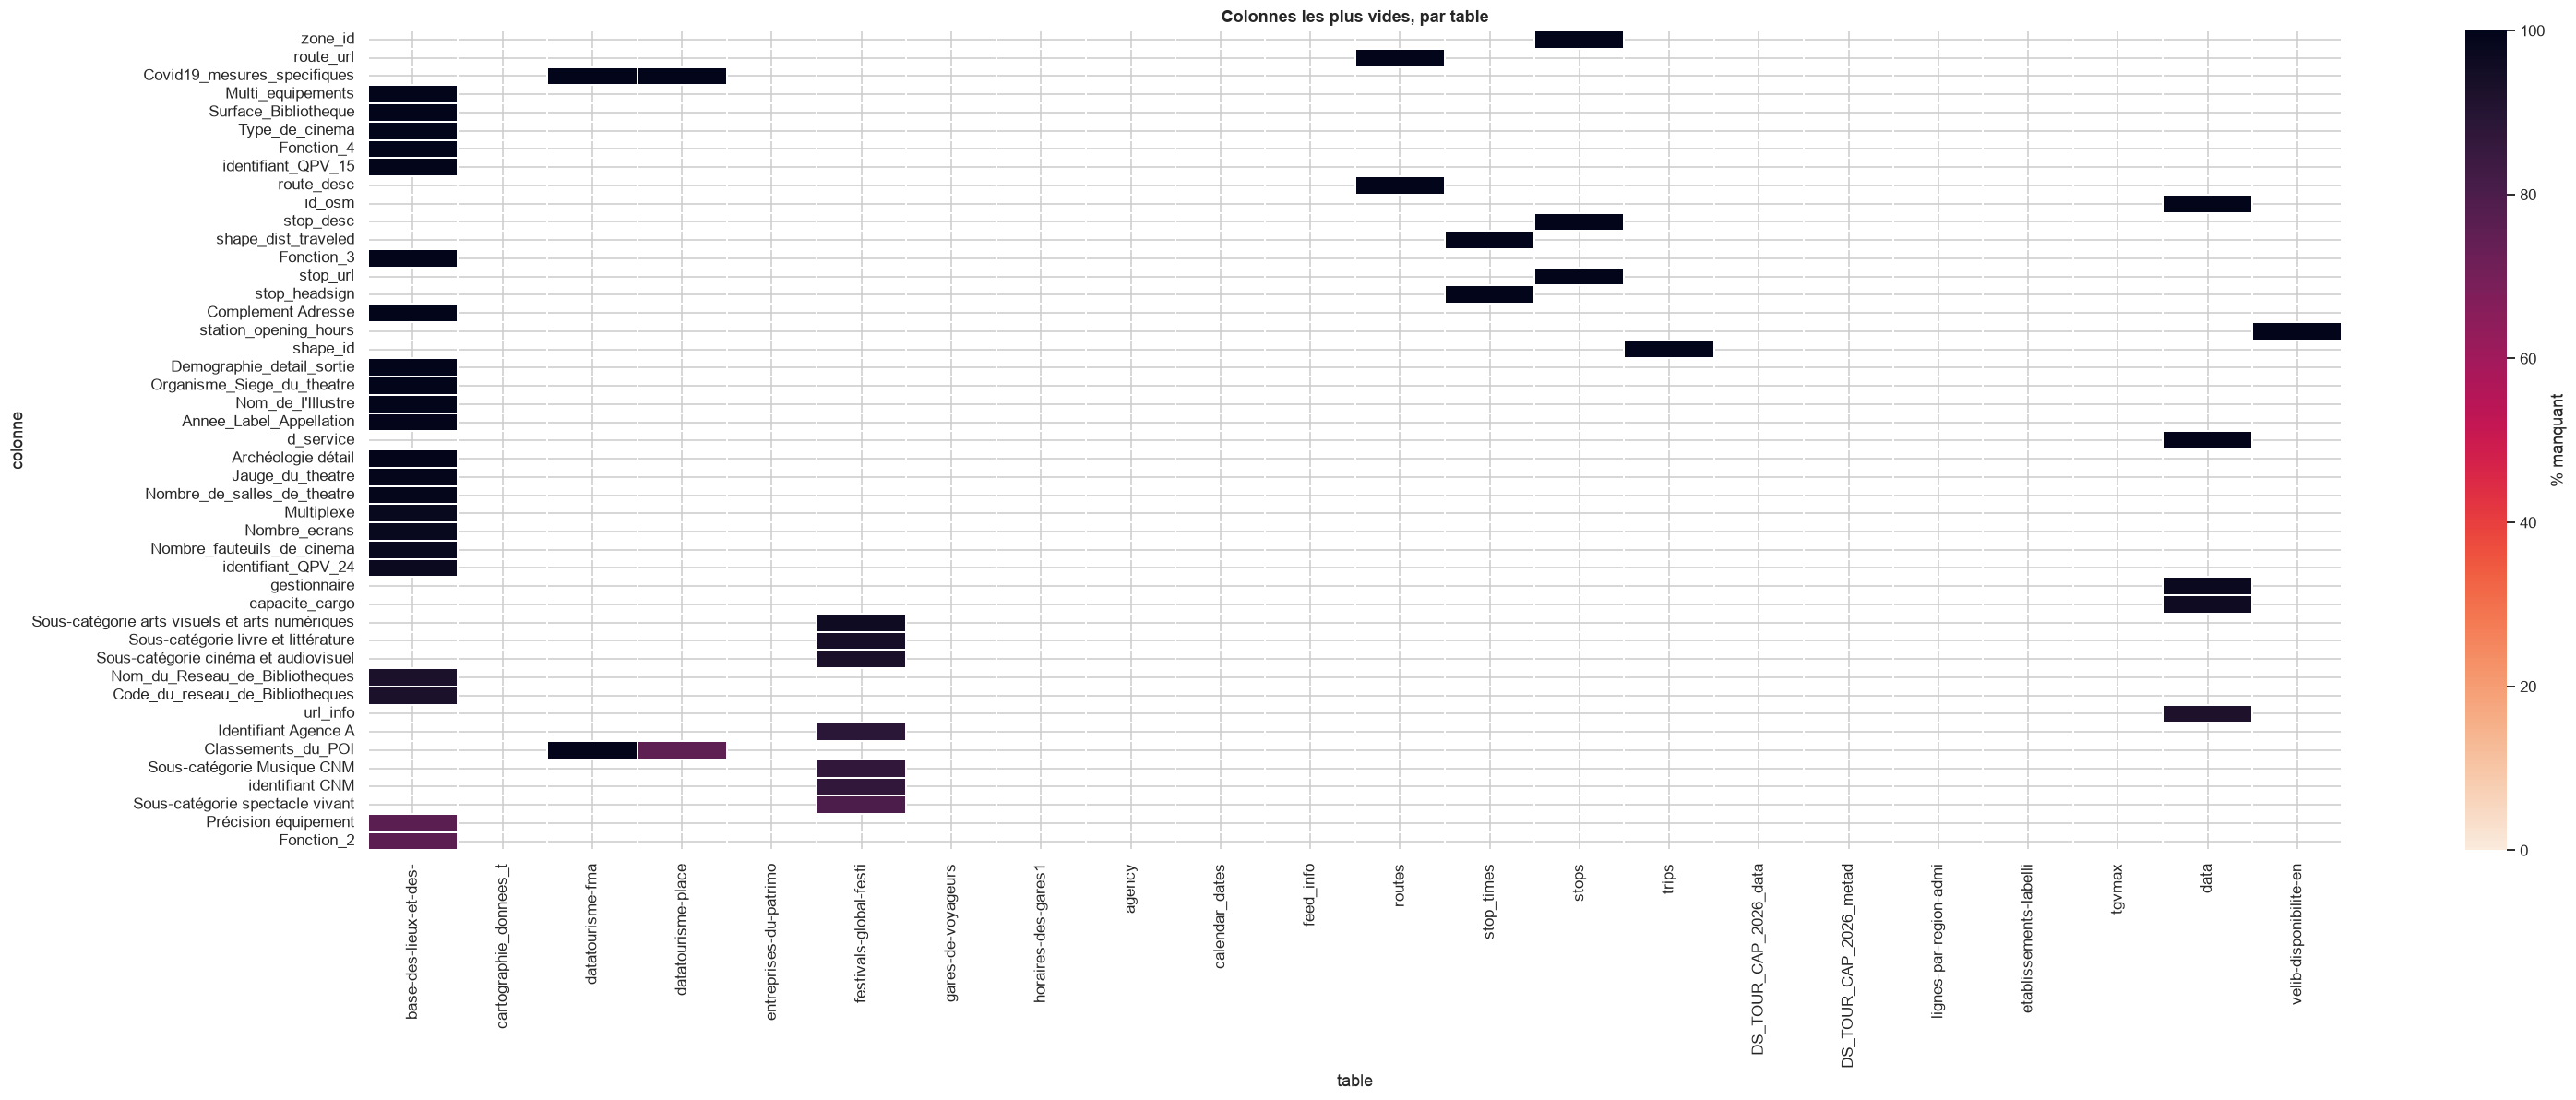

In [47]:
# Valeurs manquantes : carte de chaleur colonnes × tables (part de NaN)
tab = PROF_ALL.pivot_table(index="colonne", columns="table", values="manquants_pct")
top_cols = PROF_ALL.groupby("colonne").manquants_pct.mean().sort_values(ascending=False).index[:45]
fig, ax = plt.subplots(figsize=(1.1 * tab.shape[1] + 4, 11))
sns.heatmap(tab.loc[top_cols].rename(columns=lambda c: c.split("/")[-1][:22]), cmap="rocket_r",
            vmin=0, vmax=100, cbar_kws={"label": "% manquant"}, ax=ax, linewidths=.3, linecolor="white")
ax.set_title("Colonnes les plus vides, par table"); plt.tight_layout(); plt.show()

## 4. Analyse univariée & bivariée

Helpers génériques (histogrammes, catégories, corrélations de Spearman, outliers IQR, dates)
appliqués aux tables qui comptent le plus pour le projet.

In [48]:
def num_cols(df, key=None):
    p = PROF[key] if key else profile(df, sample=20_000)
    return [c for c in p.loc[p.sémantique == "numérique", "colonne"] if df[c].nunique() > 20]


def cat_cols(df, key=None, max_unique=60):
    p = PROF[key] if key else profile(df, sample=20_000)
    return [c for c in p.loc[p.sémantique == "catégorie", "colonne"] if 1 < df[c].nunique() <= max_unique]


def plot_numeric(df, cols, ncols=3, title=""):
    cols = cols[:12]
    if not cols:
        print("Aucune colonne numérique exploitable."); return
    nrows = math.ceil(len(cols) / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.2 * ncols, 3 * nrows), squeeze=False)
    for ax, c in zip(axes.ravel(), cols):
        x = pd.to_numeric(df[c], errors="coerce").dropna()
        skew = x.skew()
        pos = x[x > 0]
        if skew > 3 and len(pos) > 0.9 * len(x):
            ax.hist(np.log10(pos), bins=50, color="#1f4e79"); ax.set_xlabel(f"log10({c[:28]})")
        else:
            ax.hist(x, bins=50, color="#1f4e79"); ax.set_xlabel(c[:34])
        ax.set_title(f"asym. {skew:.1f} · n={len(x):,}".replace(",", " "), fontsize=9)
    for ax in axes.ravel()[len(cols):]:
        ax.axis("off")
    fig.suptitle(title, fontweight="bold"); plt.tight_layout(); plt.show()


def plot_categorical(df, cols, top=12, ncols=2, title=""):
    cols = cols[:8]
    if not cols:
        print("Aucune colonne catégorielle exploitable."); return
    nrows = math.ceil(len(cols) / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(6.5 * ncols, 3.2 * nrows), squeeze=False)
    for ax, c in zip(axes.ravel(), cols):
        vc = df[c].astype(str).value_counts().head(top)
        sns.barplot(x=vc.values, y=[v[:38] for v in vc.index], ax=ax, color="#2a7ab0")
        ax.set_title(f"{c[:40]} ({df[c].nunique()} modalités)", fontsize=10); ax.set_xlabel("")
    for ax in axes.ravel()[len(cols):]:
        ax.axis("off")
    fig.suptitle(title, fontweight="bold"); plt.tight_layout(); plt.show()


def outliers_iqr(df, cols):
    res = []
    for c in cols:
        x = pd.to_numeric(df[c], errors="coerce").dropna()
        q1, q3 = x.quantile([.25, .75]); iqr = q3 - q1
        if iqr == 0:
            continue
        n_out = ((x < q1 - 1.5 * iqr) | (x > q3 + 1.5 * iqr)).sum()
        n_ext = ((x < q1 - 3 * iqr) | (x > q3 + 3 * iqr)).sum()
        res.append(dict(colonne=c, n=len(x), min=x.min(), médiane=x.median(), max=x.max(),
                        outliers_pct=round(100 * n_out / len(x), 1), extrêmes_pct=round(100 * n_ext / len(x), 2)))
    return pd.DataFrame(res).sort_values("extrêmes_pct", ascending=False)


def corr_heatmap(df, cols, title=""):
    cols = [c for c in cols if df[c].nunique() > 5][:25]
    if len(cols) < 3:
        print("Pas assez de colonnes numériques pour une matrice de corrélation."); return
    c = df[cols].apply(pd.to_numeric, errors="coerce").corr(method="spearman")
    fig, ax = plt.subplots(figsize=(0.55 * len(cols) + 4, 0.5 * len(cols) + 3))
    sns.heatmap(c, cmap="vlag", center=0, vmin=-1, vmax=1, annot=len(cols) <= 14, fmt=".2f", ax=ax,
                square=True, cbar_kws={"shrink": .7})
    ax.set_title(f"Corrélations de Spearman {title}"); plt.tight_layout(); plt.show()


════════════════════ basilic/base-des-lieux-et-des-equipements-culturels  (86366, 54)


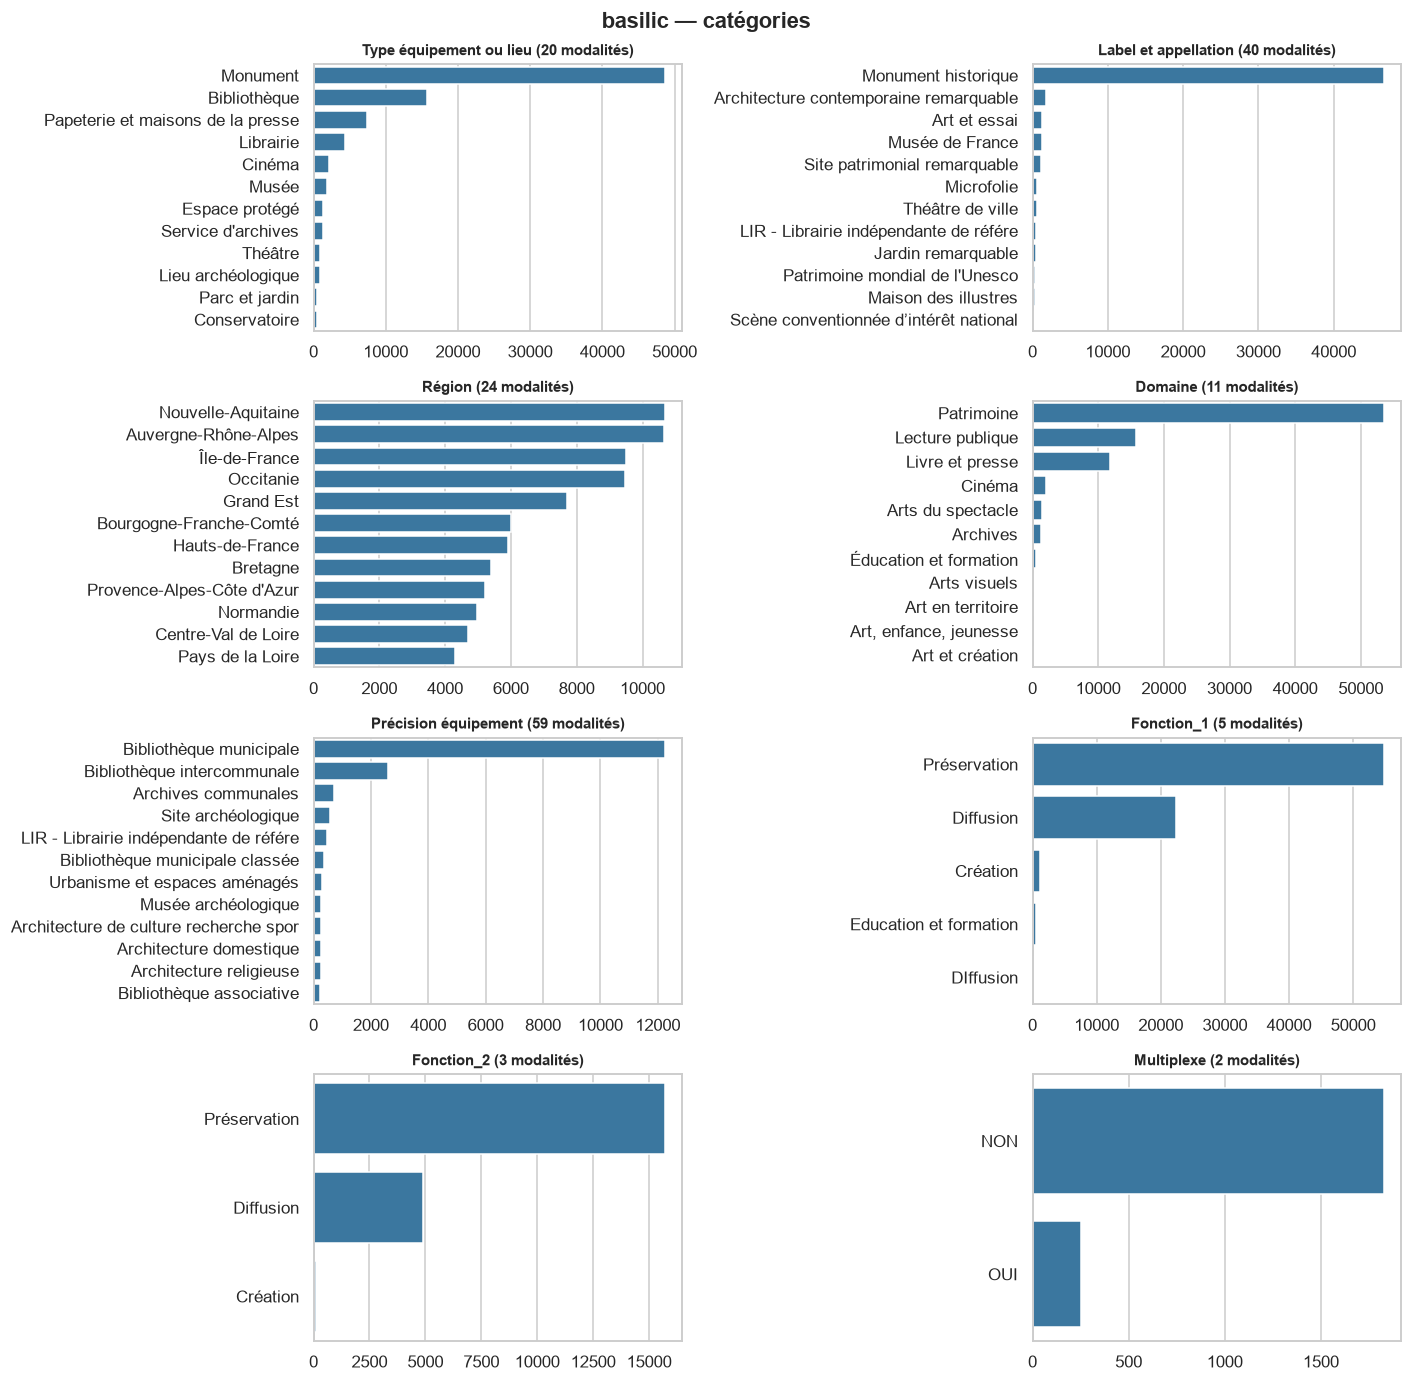

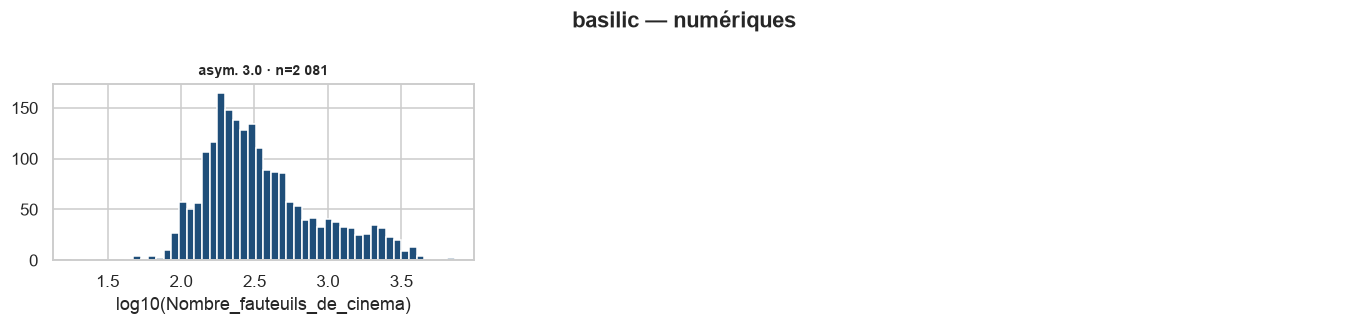


════════════════════ datatourisme_place/datatourisme-place  (354912, 14)


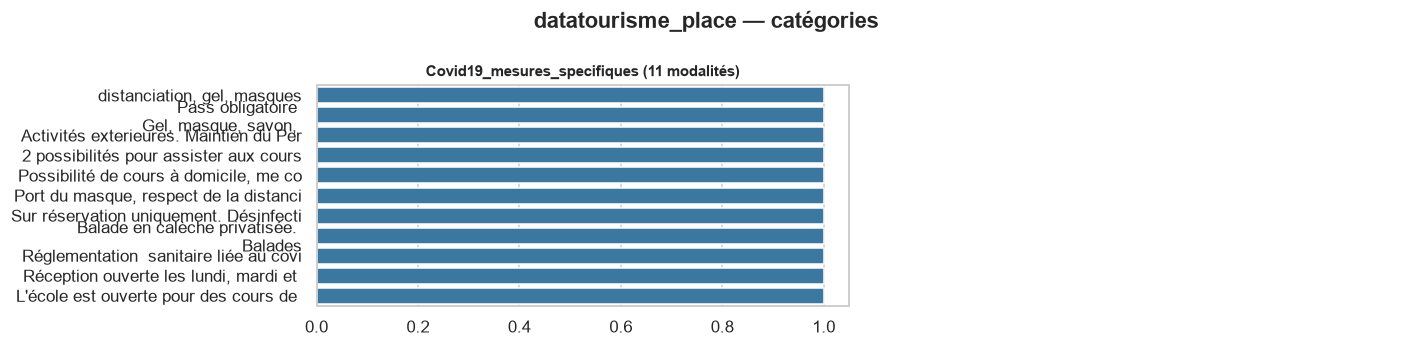

Aucune colonne numérique exploitable.

════════════════════ qualite_tourisme/etablissements-labellises-qualite-tourisme  (3604, 14)


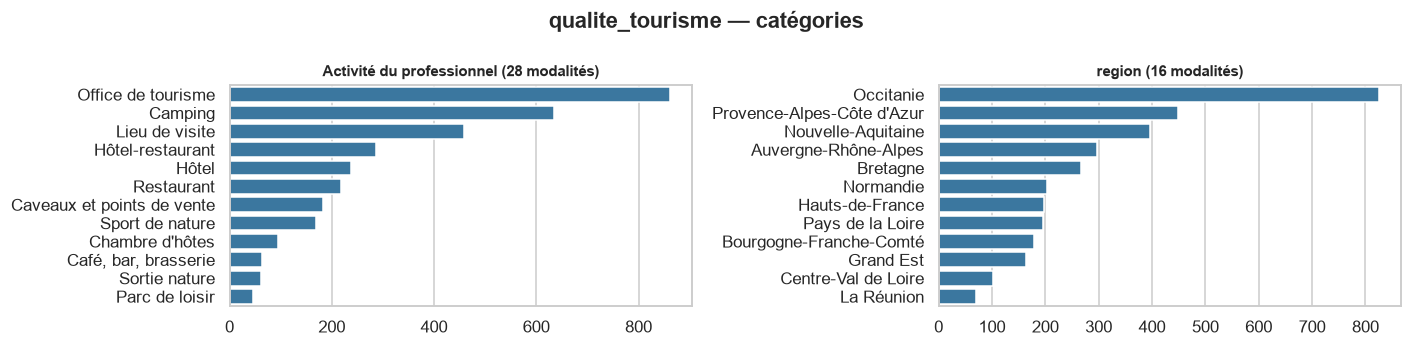

Aucune colonne numérique exploitable.

════════════════════ epv/entreprises-du-patrimoine-vivant-epv  (1267, 22)


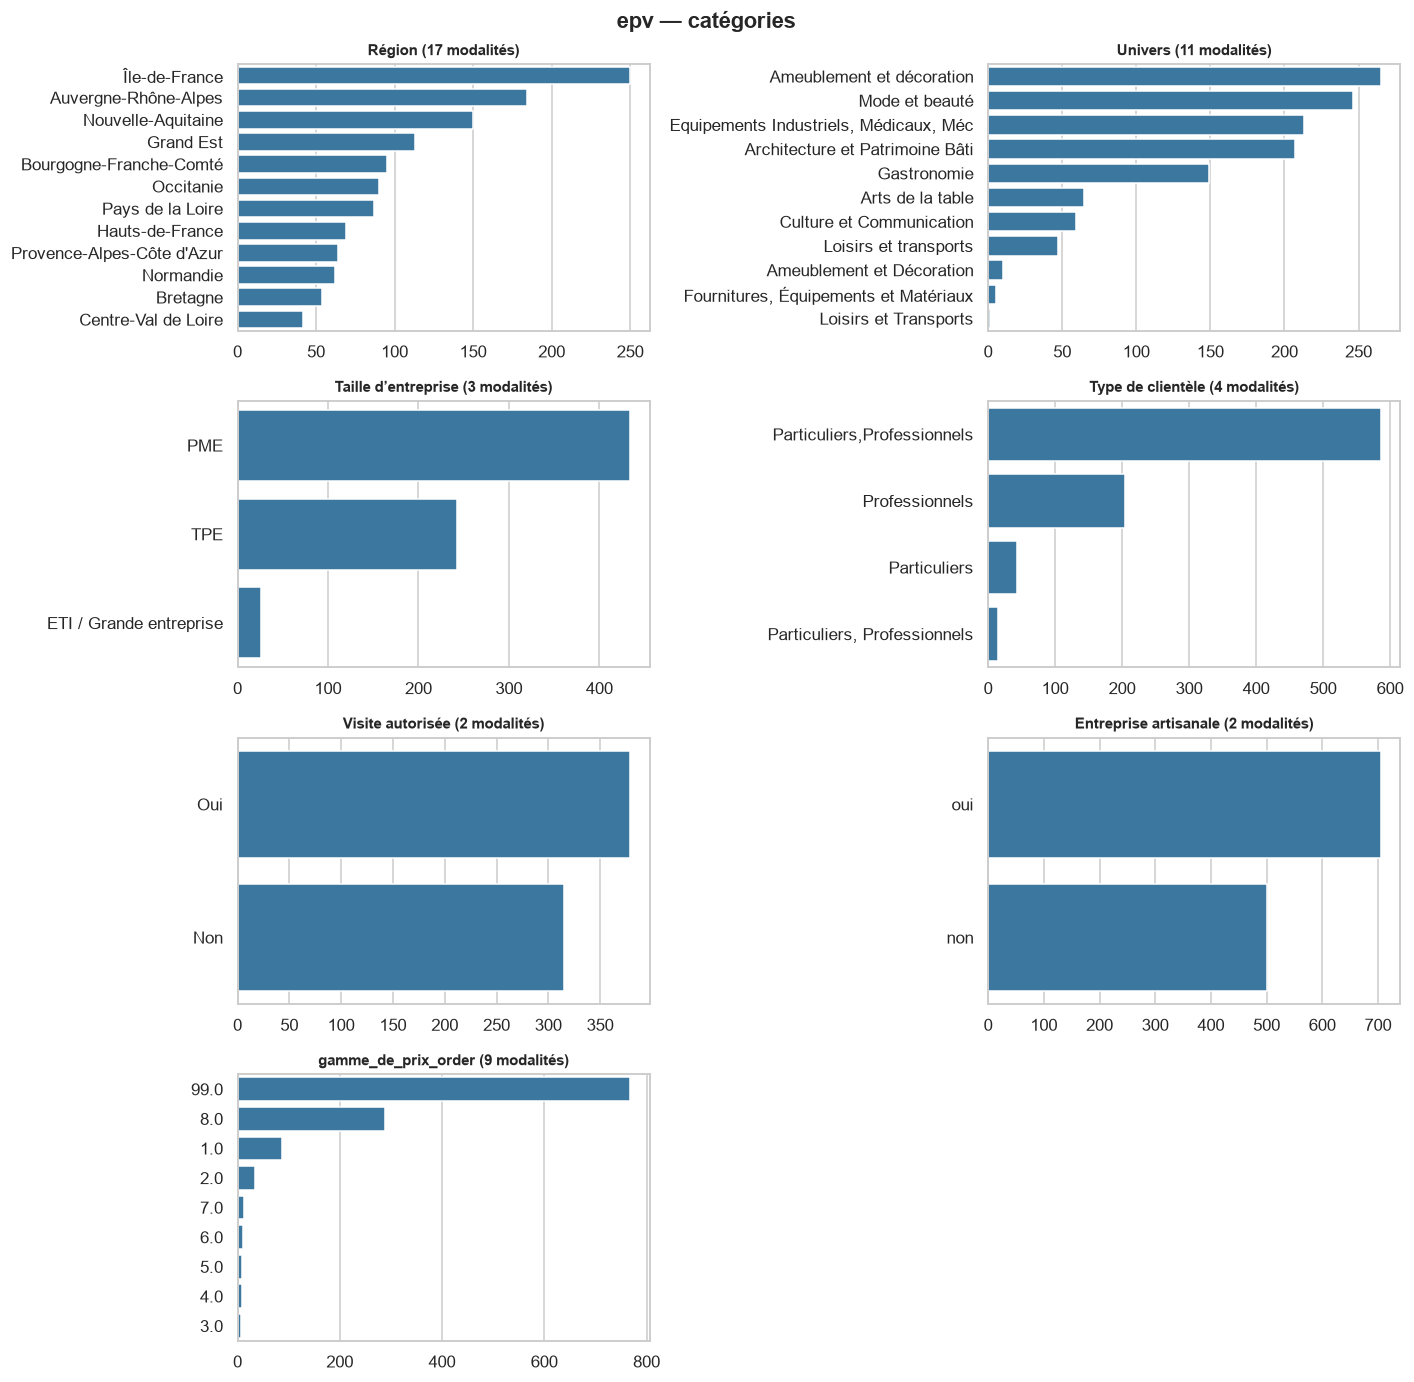

Aucune colonne numérique exploitable.

════════════════════ gares_voyageurs/gares-de-voyageurs  (2792, 7)


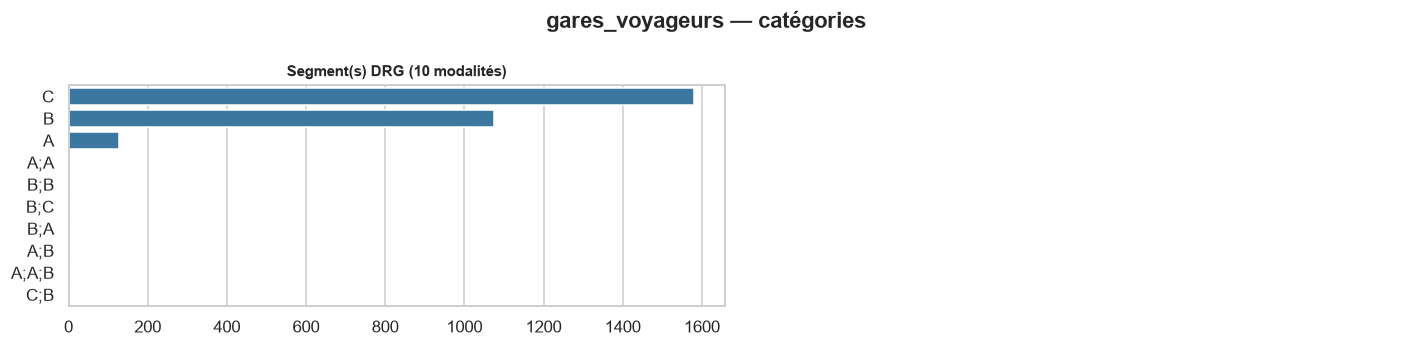

Aucune colonne numérique exploitable.


In [49]:
# ── Tables pivot du projet : analyse univariée ──────────────────────────────
for frag in ["basilic", "datatourisme_place", "qualite_tourisme", "epv", "gares_voyageurs"]:
    k = next((k for k in DF if frag in k), None)
    if not k:
        print("absent :", frag); continue
    df = DF[k]
    print(f"\n{'═' * 20} {k}  {df.shape}")
    plot_categorical(df, cat_cols(df, k), title=f"{frag} — catégories")
    plot_numeric(df, num_cols(df, k), title=f"{frag} — numériques")

In [50]:
# Outliers et corrélations (Basilic : jauges, écrans, surfaces…)
if not absent("basilic"):
    b = find("basilic")
    nc = num_cols(b, next(k for k in DF if "basilic" in k))
    display(outliers_iqr(b, nc).head(15))
    corr_heatmap(b, nc, "— Basilic")

,colonne,n,min,médiane,max,outliers_pct,extrêmes_pct
0,Nombre_fauteuils_de_cinema,2081,18.0,290.0,7358.0,13.3,8.02


Pas assez de colonnes numériques pour une matrice de corrélation.


In [51]:
# Dates : détection automatique puis chronologie (mises à jour, labellisations…)
def date_columns(df, key):
    return list(PROF[key].loc[PROF[key].sémantique == "date", "colonne"])

for k, df in DF.items():
    for c in date_columns(df, k)[:2]:
        fmt = "%Y%m%d" if df[c].dropna().astype(str).str.fullmatch(r"\d{8}").mean() > .8 else None
        d = pd.to_datetime(df[c], errors="coerce", format=fmt, utc=True).dt.tz_localize(None).dropna()
        if len(d) < 50:
            continue
        print(f"{k} · {c} : {d.min().date()} → {d.max().date()}  (n={len(d):,})".replace(",", " "))

### Garde-fou temporel : rien après 2026

Nous sommes en octobre 2026 : toute date postérieure à `HORIZON_FIN` est soit une **prévision légitime** (planning, réservation),
soit un **artefact** (récurrences dépliées jusqu'en 2100, années de saisie absurdes). On l'audite, puis on **coupe** ce qui n'a pas lieu d'être.

In [52]:
def explode_periods(df):
    """Périodes d'événements « AAAA-MM-JJ<->AAAA-MM-JJ » (plusieurs par événement) → une ligne par période."""
    pairs = df["Periodes_regroupees"].dropna().str.findall(r"(\d{4}-\d{2}-\d{2})<->(\d{4}-\d{2}-\d{2})").explode().dropna()
    out = pd.DataFrame(pairs.tolist(), index=pairs.index, columns=["deb", "fin"])
    return out.apply(pd.to_datetime, errors="coerce").dropna()


audit = []

# 1. Événements DATATourisme : récurrences matérialisées jusqu'en 2100
fma = find("datatourisme_fma")
if fma is not None and "Periodes_regroupees" in fma:
    PER = explode_periods(fma)
    n_apres = int((PER.deb > HORIZON_FIN).sum())
    n_2050 = int((PER.deb.dt.year >= 2050).sum())
    audit.append(dict(source="DATATourisme · événements", colonne="Periodes_regroupees",
                      date_max=PER.fin.max().date(), lignes_après_horizon=n_apres,
                      nature=f"annonces + récurrences dépliées jusqu'en 2100 ({n_2050:,} périodes après 2050 = artefact)".replace(",", " "),
                      action="périodes > horizon supprimées, fins écrêtées à l'horizon"))
    PER = PER[(PER.deb <= HORIZON_FIN) & (PER.fin >= PER.deb)].assign(fin=lambda d: d.fin.clip(upper=HORIZON_FIN))
    EVENTS = PER.groupby(level=0).agg(deb=("deb", "min"), fin=("fin", "max"), periodes=("deb", "size"))
    EVENTS_ACTIFS = EVENTS[EVENTS.fin >= REF_DATE]            # en cours ou à venir, avant l'horizon
    print(f"Événements : {len(fma):,} → {len(EVENTS):,} avec au moins une période avant l'horizon → "
          f"{len(EVENTS_ACTIFS):,} en cours ou à venir ({(EVENTS.fin < REF_DATE).sum():,} déjà passés)".replace(",", " "))

# 2. GTFS SNCF : planning futur légitime, mais hors périmètre → coupé
k_cd = next((k for k in DF if "gtfs/calendar_dates" in k), None)
if k_cd:
    d = pd.to_datetime(DF[k_cd]["date"].astype(str), format="%Y%m%d", errors="coerce")
    audit.append(dict(source="GTFS SNCF · calendar_dates", colonne="date", date_max=d.max().date(),
                      lignes_après_horizon=int((d > HORIZON_FIN).sum()),
                      nature="prévision légitime (planning publié jusqu'à feed_end_date)",
                      action="lignes > horizon supprimées"))
    DF[k_cd] = DF[k_cd][d <= HORIZON_FIN]

# 3. TGVmax : fenêtre de réservation, déjà ≤ horizon
k_t = next((k for k in DF if "tgvmax/tgvmax" in k), None)
if k_t:
    d = pd.to_datetime(DF[k_t]["DATE"], errors="coerce")
    audit.append(dict(source="TGVmax", colonne="DATE", date_max=d.max().date(), lignes_après_horizon=int((d > HORIZON_FIN).sum()),
                      nature="prévision légitime (fenêtre de réservation ~30 jours)", action="aucune"))

# 4. EPV : échéance de labellisation (attribut d'entreprise, pas un événement)
k_e = next((k for k in DF if "epv/" in k), None)
if k_e and "Date de fin de labellisation" in DF[k_e]:
    d = pd.to_datetime(DF[k_e]["Date de fin de labellisation"], errors="coerce")
    audit.append(dict(source="EPV", colonne="Date de fin de labellisation", date_max=d.max().date(),
                      lignes_après_horizon=int((d > HORIZON_FIN).sum()),
                      nature="échéance contractuelle du label (5 ans)", action="conservée (supprimer la ligne retirerait l'entreprise)"))

# 5. Festivals : année de création absurde (ex. 31564)
k_f = next((k for k in DF if "festivals/" in k), None)
if k_f:
    ycol = next((c for c in DF[k_f].columns if c.startswith("Année de création")), None)
    if ycol:
        y = pd.to_numeric(DF[k_f][ycol], errors="coerce")
        bad = y > REF_DATE.year
        audit.append(dict(source="Festivals", colonne=ycol, date_max=int(y.max()), lignes_après_horizon=int(bad.sum()),
                          nature="erreur de saisie (année impossible)", action="valeur mise à vide (NaN)"))
        DF[k_f][ycol] = y.where(~bad)

AUDIT_TEMPOREL = pd.DataFrame(audit)
display(AUDIT_TEMPOREL.style.hide(axis="index"))

Événements : 77 164 → 68 676 avec au moins une période avant l'horizon → 56 354 en cours ou à venir (12 322 déjà passés)


source,colonne,date_max,lignes_après_horizon,nature,action
DATATourisme · événements,Periodes_regroupees,2926-09-27,65736,annonces + récurrences dépliées jusqu'en 2100 (19 153 périodes après 2050 = artefact),"périodes > horizon supprimées, fins écrêtées à l'horizon"
GTFS SNCF · calendar_dates,date,2027-03-31,115914,prévision légitime (planning publié jusqu'à feed_end_date),lignes > horizon supprimées
TGVmax,DATE,2026-11-05,0,prévision légitime (fenêtre de réservation ~30 jours),aucune
EPV,Date de fin de labellisation,2031-08-04,1124,échéance contractuelle du label (5 ans),conservée (supprimer la ligne retirerait l'entreprise)
Festivals,Année de création du festival,31564,2,erreur de saisie (année impossible),valeur mise à vide (NaN)


## 5. Géographie

Six formats de coordonnées coexistent dans les sources (`lat, lon` en chaîne, `[lon,lat]` JSON, colonnes séparées…).
On les harmonise en `(lat, lon)` WGS84, puis on interroge leur **qualité** : hors France, latitude/longitude inversées, précision, points empilés.

In [53]:
def pair_from_strings(s, order="latlon"):
    """Extrait deux nombres d'une chaîne ('48.8, 2.3' ou '[2.3,48.8]'). order='lonlat' pour les JSON GeoJSON."""
    e = s.astype(str).str.extract(r"(-?\d+(?:\.\d+)?)\s*,\s*(-?\d+(?:\.\d+)?)").astype(float)
    return (e[0], e[1]) if order == "latlon" else (e[1], e[0])


def raw_decimals(series):
    """Nombre de décimales lues dans le texte brut (révèle la précision de géocodage)."""
    return series.astype(str).str.extract(r"\.(\d+)")[0].str.len().fillna(0)


# (nom du calque, fragment de table, colonne(s) de coordonnées, mode)
LAYERS_SPEC = [
    ("gares",          "gares_voyageurs",    "Position géographique",          "pair_latlon"),
    ("gtfs_arrêts",    "gtfs/stops",         ("stop_lat", "stop_lon"),         "cols"),
    ("basilic",        "basilic",            ("Latitude", "Longitude"),        "cols"),
    ("datatourisme",   "datatourisme_place", ("Latitude", "Longitude"),        "cols"),
    ("événements",     "datatourisme_fma",   ("Latitude", "Longitude"),        "cols"),
    ("qualité_tourisme", "qualite_tourisme", "coordonnees_geographiques",      "pair_latlon"),
    ("epv",            "epv",                "geolocetablissement",            "pair_latlon"),
    ("velib",          "vls_paris_velib",    "Coordonnées géographiques",      "pair_latlon"),
    ("vélo_gares_cvl", "velo_stationnement", "coordonneesxy",                  "pair_lonlat"),
    ("lignes_ferrées", "lignes_par_region",  ("Y_D_WGS84", "X_D_WGS84"),       "cols"),
]

GEO = {}
for name, frag, spec, mode in LAYERS_SPEC:
    df = next((DF[k] for k in DF if frag in k), None)
    if df is None or (isinstance(spec, str) and spec not in df) or (isinstance(spec, tuple) and not set(spec) <= set(df)):
        print("calque ignoré :", name); continue
    if mode == "cols":
        lat, lon = pd.to_numeric(df[spec[0]], errors="coerce"), pd.to_numeric(df[spec[1]], errors="coerce")
        dec = raw_decimals(df[spec[0]])
    else:
        lat, lon = pair_from_strings(df[spec], "latlon" if mode == "pair_latlon" else "lonlat")
        dec = raw_decimals(lat.astype(str))
    GEO[name] = pd.DataFrame({"lat": lat, "lon": lon, "dec": dec}, index=df.index)

def verdict(g):
    ok = g.dropna(subset=["lat", "lon"])
    metro = ok.lat.between(41, 51.5) & ok.lon.between(-5.5, 10)
    swapped = ok.lat.between(-5.5, 10) & ok.lon.between(41, 51.5)
    zero = (ok.lat == 0) & (ok.lon == 0)
    return dict(points=len(g), sans_coord_pct=round(100 * (1 - len(ok) / len(g)), 1),
                métropole_pct=round(100 * metro.mean(), 1), outre_mer_ou_ailleurs_pct=round(100 * (~metro & ~swapped & ~zero).mean(), 1),
                lat_lon_inversés=int(swapped.sum()), zéro_zéro=int(zero.sum()),
                décimales_médianes=float(g.dec.median()), precision_2dec_ou_moins_pct=round(100 * (g.dec <= 2).mean(), 1),
                coord_dupliquées_pct=round(100 * ok.duplicated(["lat", "lon"], keep=False).mean(), 1))

QUALITE_GEO = pd.DataFrame({n: verdict(g) for n, g in GEO.items()}).T
display(QUALITE_GEO.style.background_gradient(subset=["coord_dupliquées_pct", "sans_coord_pct"], cmap="Oranges").format(precision=1))

,points,sans_coord_pct,métropole_pct,outre_mer_ou_ailleurs_pct,lat_lon_inversés,zéro_zéro,décimales_médianes,precision_2dec_ou_moins_pct,coord_dupliquées_pct
gares,2792.0,0.0,100.0,0.0,0.0,0.0,7.0,0.0,0.0
gtfs_arrêts,8829.0,0.0,99.8,0.2,0.0,0.0,6.0,0.0,100.0
basilic,86366.0,0.0,98.5,1.5,0.0,0.0,6.0,0.1,33.5
datatourisme,354912.0,0.0,98.5,1.5,0.0,10.0,6.0,0.1,17.2
événements,77164.0,0.0,99.9,0.1,2.0,0.0,6.0,0.1,60.1
qualité_tourisme,3604.0,4.0,96.6,3.4,0.0,0.0,6.0,4.1,5.0
epv,1267.0,0.0,99.6,0.4,0.0,0.0,6.0,0.0,2.3
velib,1519.0,0.0,100.0,0.0,0.0,0.0,12.0,0.0,0.0
vélo_gares_cvl,167.0,0.0,100.0,0.0,0.0,0.0,13.0,0.0,0.0
lignes_ferrées,2909.0,0.0,100.0,0.0,0.0,0.0,14.0,0.0,100.0


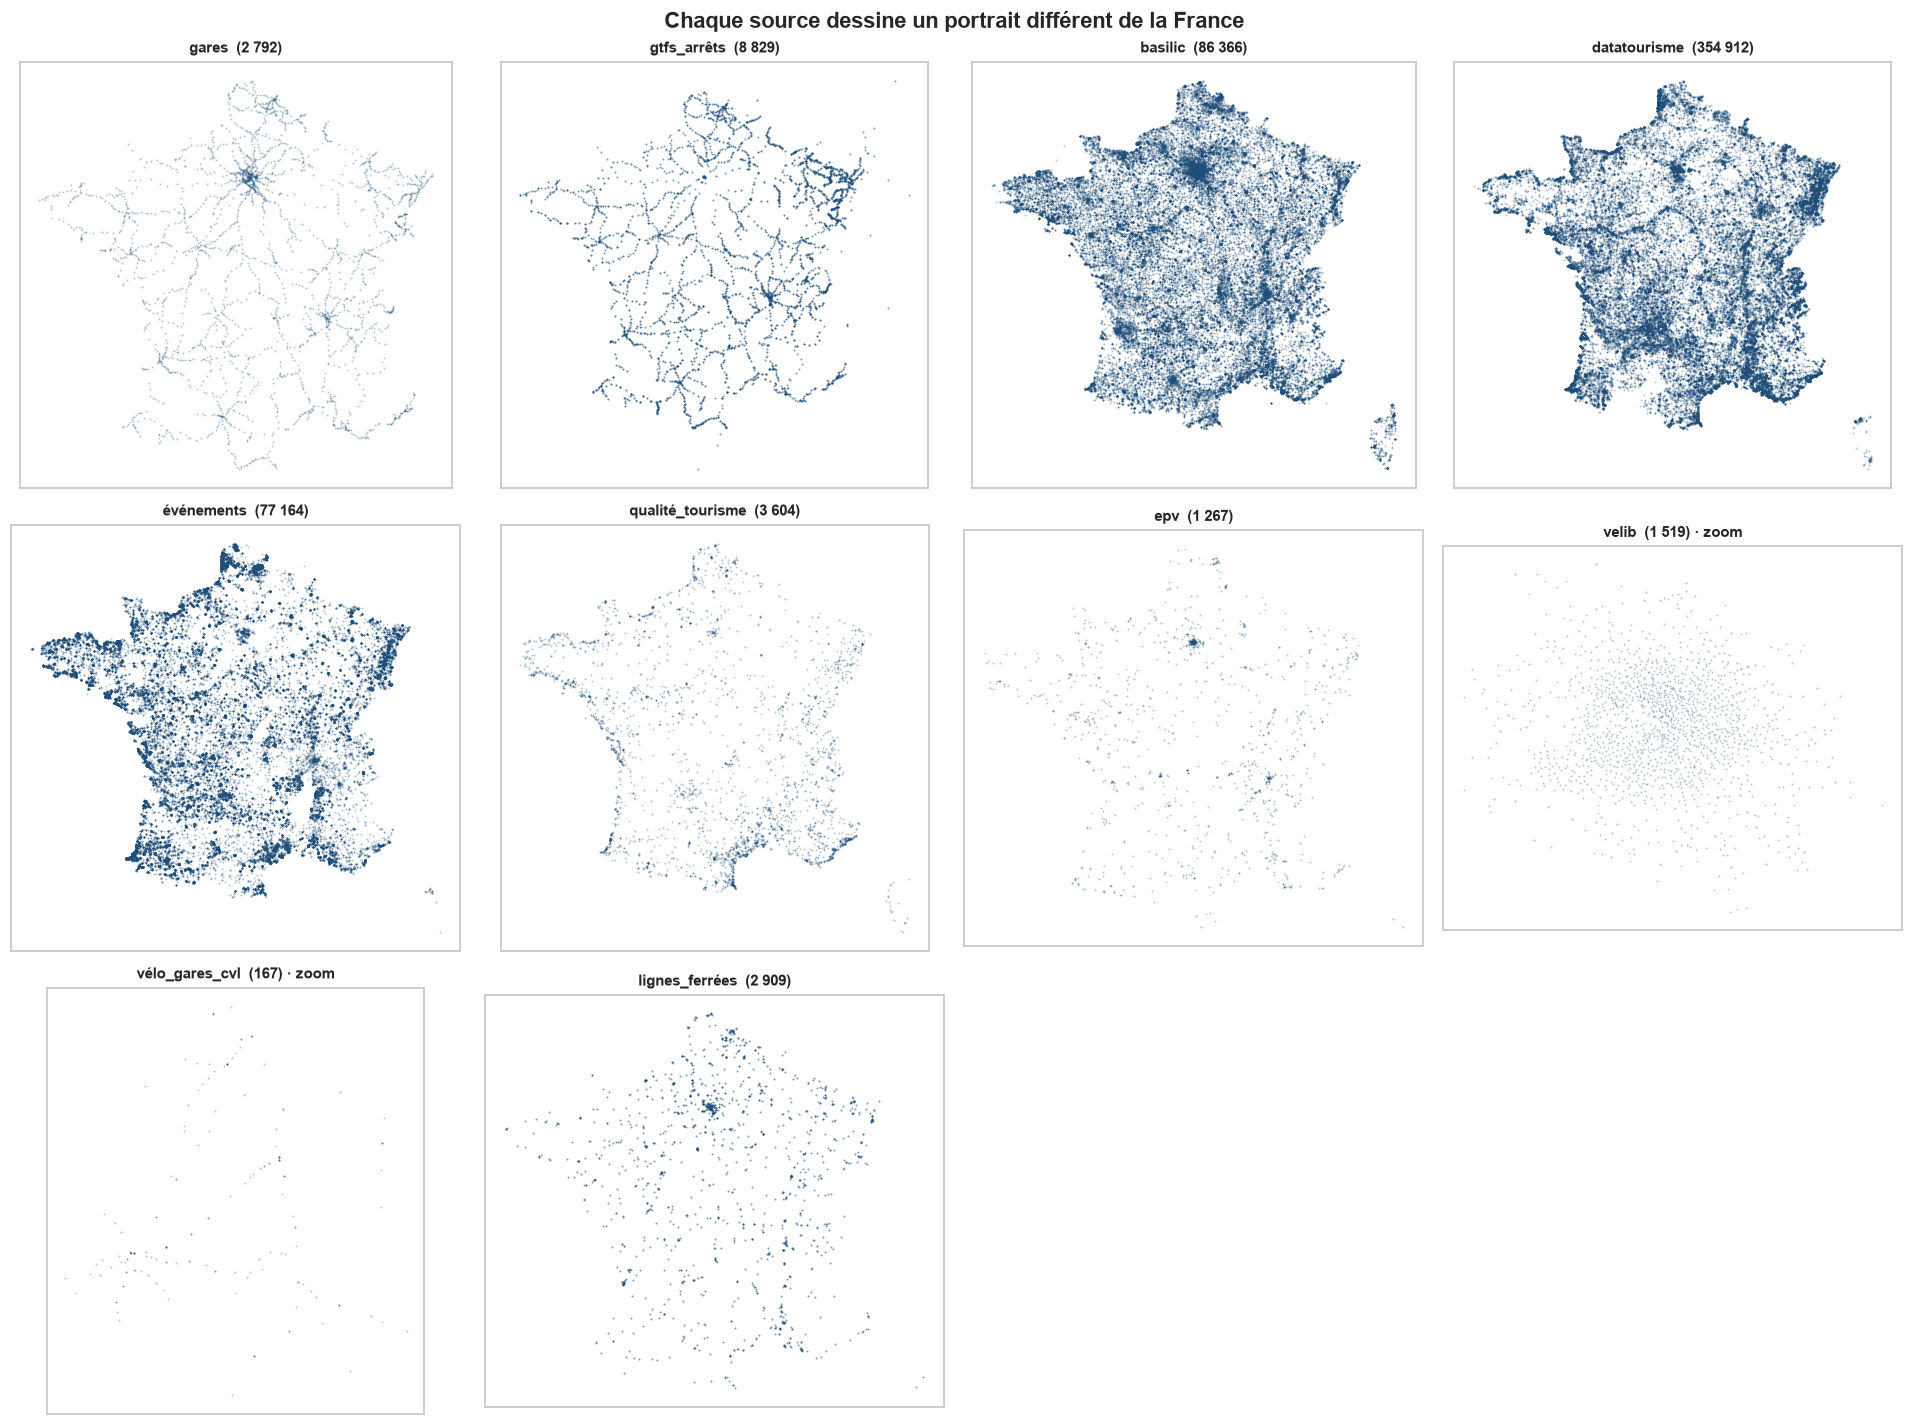

In [54]:
def in_metro(g):
    return g[g.lat.between(41, 51.5) & g.lon.between(-5.5, 10)]

n = len(GEO)
ncols = 4
nrows = math.ceil(n / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(4.4 * ncols, 4.4 * nrows), squeeze=False)
for ax, (name, g) in zip(axes.ravel(), GEO.items()):
    m = in_metro(g)
    m = m.sample(min(len(m), 60_000), random_state=SEED)
    ax.scatter(m.lon, m.lat, s=1.5, alpha=.35, c="#1f4e79", linewidths=0)
    zoom = " · zoom" if (m.lon.max() - m.lon.min()) < 3 else ""
    ax.set_aspect(1 / math.cos(math.radians(46.5))); ax.set_title(f"{name}  ({len(g):,}){zoom}".replace(",", " "), fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])
for ax in axes.ravel()[n:]:
    ax.axis("off")
fig.suptitle("Chaque source dessine un portrait différent de la France", fontweight="bold"); plt.tight_layout(); plt.show()

,point_le_plus_repete,occurrences,points_uniques
calque,,,
gares,"42.4324, 1.9487",1,2792
gtfs_arrêts,"43.3363, 3.2189",9,3432
basilic,"47.5870, -3.0840",74,66598
datatourisme,"48.3289, 4.1028",63,317036
événements,"48.6931, 6.1794",172,39891
qualité_tourisme,"43.6760, 7.2283",4,3363
epv,"48.8755, 2.3430",3,1252
velib,"48.7434, 2.4026",1,1519
vélo_gares_cvl,"46.5919, 1.5185",1,167


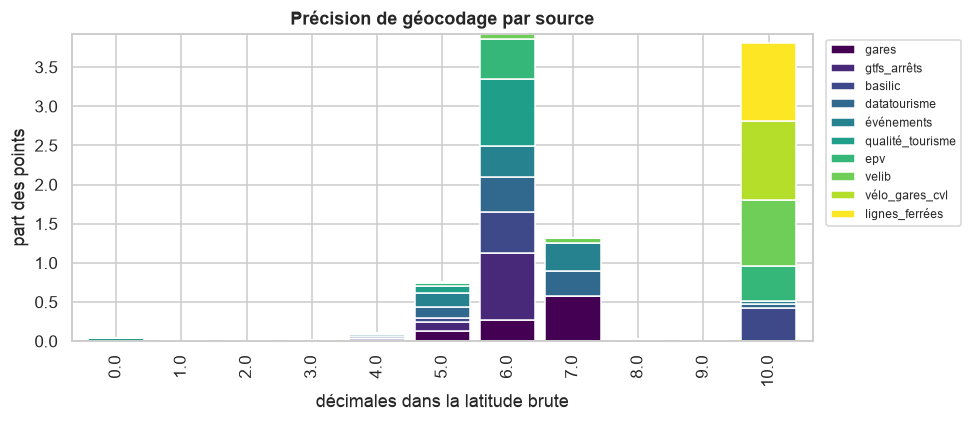

In [55]:
# Points "empilés" : la même coordonnée répétée = géocodage au centroïde de la commune (ou saisie par défaut)
rows = []
for name, g in GEO.items():
    vc = g.dropna(subset=["lat", "lon"]).groupby(["lat", "lon"]).size().sort_values(ascending=False)
    if len(vc):
        rows.append(dict(calque=name, point_le_plus_repete=f"{vc.index[0][0]:.4f}, {vc.index[0][1]:.4f}",
                         occurrences=int(vc.iloc[0]), points_uniques=len(vc)))
display(pd.DataFrame(rows).set_index("calque"))

# Précision du géocodage : distribution des décimales (6 décimales ≈ 10 cm, 2 ≈ 1 km, 0 = arrondi à l'entier)
dec = pd.concat({n: g.dec.clip(upper=10).value_counts(normalize=True) for n, g in GEO.items()}, axis=1).fillna(0).sort_index()
ax = dec.plot(kind="bar", stacked=True, figsize=(9, 4), colormap="viridis", width=.85)
ax.set_xlabel("décimales dans la latitude brute"); ax.set_ylabel("part des points"); ax.set_title("Précision de géocodage par source")
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8); plt.tight_layout(); plt.show()

## 6. Cœur du projet : tourisme × gare

À quelle distance de la gare voyageurs la plus proche se trouve chaque site culturel / touristique ?
Distance orthodromique (BallTree haversine) — une borne basse de la vraie distance d'accès, mais un bon indicateur
de **désert ferroviaire culturel**.

Gares en Corse dans gares_voyageurs : 0 (le réseau corse est une source à part : chemins_de_fer_corse) → la Corse est exclue des distances.


,sites,médiane_km,p90_km,dans_5km_pct,dans_10km_pct,au_delà_25km_pct
basilic,84501.0,3.6,18.3,56.7,74.2,3.9
datatourisme,348899.0,6.0,20.4,44.9,65.8,4.6
événements,77030.0,3.2,18.4,59.4,74.9,3.7
qualité_tourisme,3322.0,5.6,21.6,46.9,65.0,5.9
epv,1260.0,2.5,15.3,66.9,79.8,3.4
vélo_gares_cvl,167.0,0.0,0.1,100.0,100.0,0.0


vélo_gares_cvl = groupe témoin : ces parkings sont DANS les gares, la distance doit être ≈ 0.


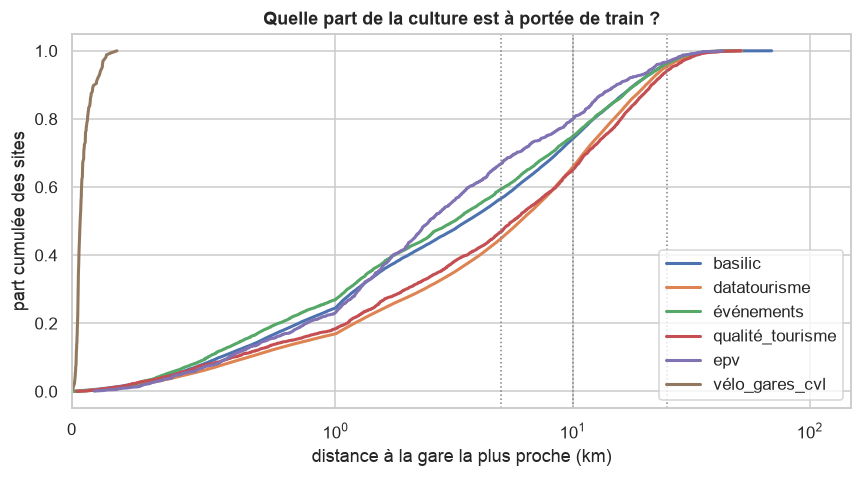

In [56]:
from sklearn.neighbors import BallTree

R_TERRE = 6371.0

def nearest_station_km(points, stations):
    tree = BallTree(np.radians(stations[["lat", "lon"]].values), metric="haversine")
    d, i = tree.query(np.radians(points[["lat", "lon"]].values), k=1)
    return d[:, 0] * R_TERRE, i[:, 0]

if "gares" not in GEO:
    print("⚠ Calque 'gares' absent — ajouter gares_voyageurs dans SOURCES.")
else:
    stations = in_metro(GEO["gares"]).dropna().reset_index(drop=True)
    corse = lambda g: (g.lat < 43.1) & (g.lon > 8.4)
    print(f"Gares en Corse dans gares_voyageurs : {int(corse(stations).sum())} "
          "(le réseau corse est une source à part : chemins_de_fer_corse) → la Corse est exclue des distances.")
    DIST = {}
    for name in ["basilic", "datatourisme", "événements", "qualité_tourisme", "epv", "vélo_gares_cvl"]:
        if name not in GEO:
            continue
        p = in_metro(GEO[name]).dropna(subset=["lat", "lon"])
        p = p[~corse(p)]
        km, _ = nearest_station_km(p, stations)
        DIST[name] = pd.Series(km, index=p.index)
    SYNTH = pd.DataFrame({n: dict(sites=len(s), médiane_km=s.median(), p90_km=s.quantile(.9),
                                   dans_5km_pct=100 * (s <= 5).mean(), dans_10km_pct=100 * (s <= 10).mean(),
                                   au_delà_25km_pct=100 * (s > 25).mean()) for n, s in DIST.items()}).T
    display(SYNTH.style.format(precision=1).background_gradient(subset=["médiane_km"], cmap="YlOrRd"))
    print("vélo_gares_cvl = groupe témoin : ces parkings sont DANS les gares, la distance doit être ≈ 0.")

    fig, ax = plt.subplots(figsize=(8, 4.5))
    for n, s in DIST.items():
        x = np.sort(s.values); ax.plot(x, np.arange(1, len(x) + 1) / len(x), label=n, lw=2)
    ax.set_xscale("symlog", linthresh=1); ax.set_xlim(0, 150); ax.set_xlabel("distance à la gare la plus proche (km)")
    ax.set_ylabel("part cumulée des sites"); ax.set_title("Quelle part de la culture est à portée de train ?")
    for r in (5, 10, 25):
        ax.axvline(r, color="grey", ls=":", lw=1)
    ax.legend(); plt.tight_layout(); plt.show()

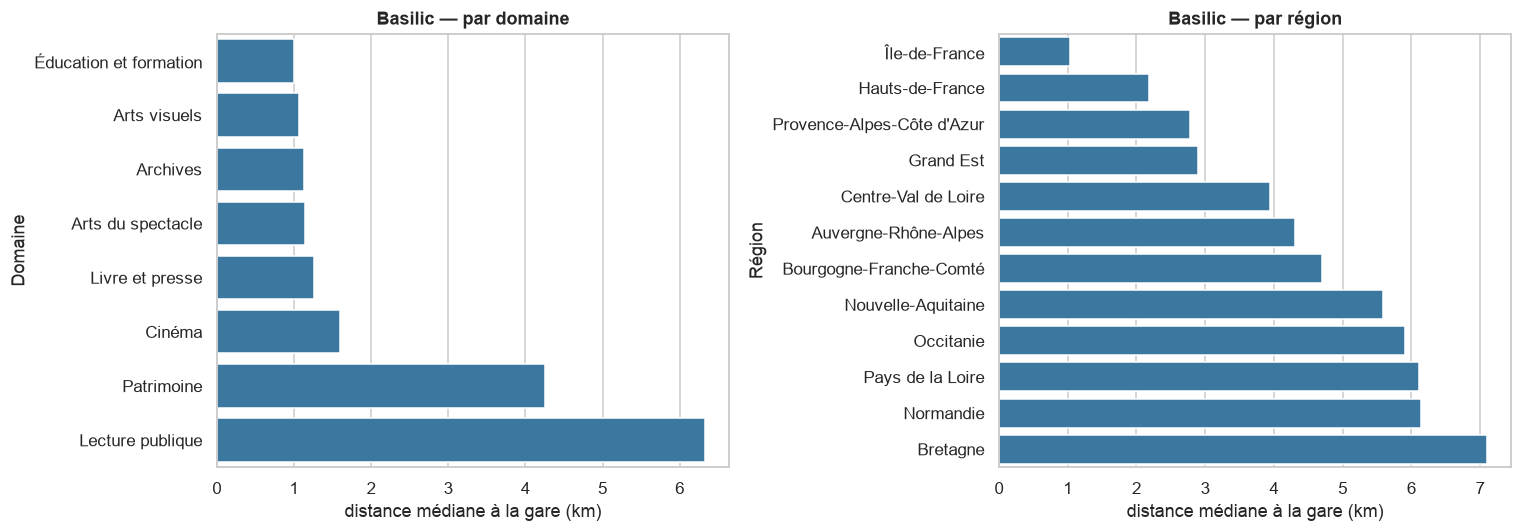

sites    km
Département             libelle_geographique               
Alpes-Maritimes         Saint-Étienne-de-Tinée     10  50.3
Gers                    Eauze                      11  46.3
Finistère               Ouessant                    9  46.2
Alpes-de-Haute-Provence Castellane                  8  43.0
Gard                    Le Vigan                   11  40.9
Gers                    Montréal                    9  36.5
Morbihan                Pontivy                    30  36.0
                        Forges de Lanouée           8  35.5
Drôme                   Nyons                       8  34.7
Tarn                    Lacaune                     8  34.7
Côtes-d'Armor           Guerlédan                   8  34.7
Côte-d'Or               Saulieu                    13  33.9
Savoie                  Bonneval-sur-Arc           13  33.6
Finistère               Audierne                    9  33.6
Indre                   La Châtre                  18  33.6

In [57]:
# Qui est loin des gares ? Distance médiane par domaine et par région (Basilic)
if "DIST" in globals() and "basilic" in DIST and find("basilic") is not None:
    b = find("basilic").loc[DIST["basilic"].index].assign(km=DIST["basilic"])
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    b = b[b.Région.ne("Corse")] if "Région" in b else b
    for ax, col in zip(axes, ["Domaine", "Région"]):
        if col not in b: ax.axis("off"); continue
        g = b.groupby(col).km.agg(["median", "size"]).query("size >= 30").sort_values("median")
        sns.barplot(x=g["median"], y=g.index, ax=ax, color="#2a7ab0")
        ax.set_xlabel("distance médiane à la gare (km)"); ax.set_title(f"Basilic — par {col.lower()}")
    plt.tight_layout(); plt.show()

    # Les 15 communes les plus « gare-dépendantes » : beaucoup de sites, gare lointaine
    c = (b.groupby(["Département", "libelle_geographique"]).agg(sites=("km", "size"), km=("km", "median"))
           .query("sites >= 8").sort_values("km", ascending=False).head(15))
    display(c.round(1))

## 7. TGVmax

Photographie des places TGVmax ouvertes (OUI) ou non, sur ~30 jours glissants.
On regarde le rythme hebdomadaire, l'heure de départ, les axes, et on traite le réseau comme un **graphe** origine → destination.

358 868 trajets-jours · 2026-10-06 → 2026-11-05 · 1288 numéros de train · 16.2% de places MAX ouvertes


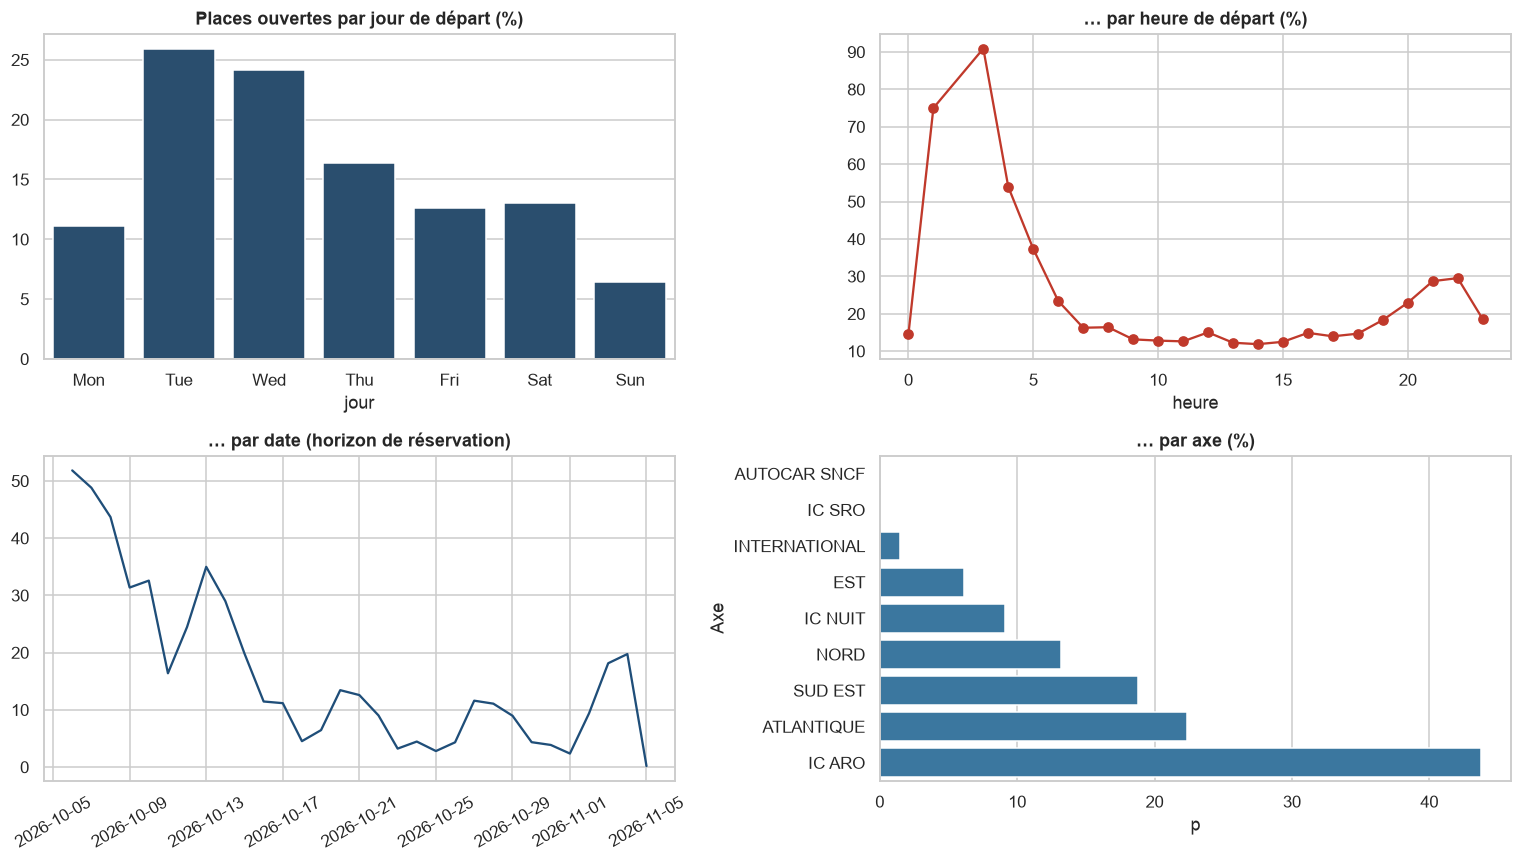

In [58]:
TGV = None
if not absent("tgvmax"):
    t = find("tgvmax").copy()
    dispo_col = [c for c in t.columns if c.lower().startswith("disponibilit")][0]
    t["dispo"] = t[dispo_col].astype(str).str.upper().eq("OUI")
    t["date"] = pd.to_datetime(t["DATE"])
    t["jour"] = t.date.dt.day_name()
    t["h_dep"] = pd.to_datetime(t.Heure_depart, format="%H:%M", errors="coerce")
    t["h_arr"] = pd.to_datetime(t.Heure_arrivee, format="%H:%M", errors="coerce")
    t["duree_min"] = ((t.h_arr - t.h_dep).dt.total_seconds() / 60) % (24 * 60)
    t["heure"] = t.h_dep.dt.hour
    t["delai_j"] = (t.date - t.date.min()).dt.days
    TGV = t
    print(f"{len(t):,} trajets-jours · {t.date.min().date()} → {t.date.max().date()} · "
          f"{t.TRAIN_NO.nunique()} numéros de train · {100 * t.dispo.mean():.1f}% de places MAX ouvertes".replace(",", " "))

    ordre = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
    fig, axes = plt.subplots(2, 2, figsize=(14, 8))
    j = t.groupby("jour").dispo.mean().reindex(ordre) * 100
    sns.barplot(x=j.index.str[:3], y=j.values, ax=axes[0, 0], color="#1f4e79"); axes[0, 0].set_title("Places ouvertes par jour de départ (%)")
    h = t.groupby("heure").dispo.mean() * 100
    axes[0, 1].plot(h.index, h.values, marker="o", color="#c0392b"); axes[0, 1].set_title("… par heure de départ (%)"); axes[0, 1].set_xlabel("heure")
    d = t.groupby("date").dispo.mean() * 100
    axes[1, 0].plot(d.index, d.values, color="#1f4e79"); axes[1, 0].set_title("… par date (horizon de réservation)"); axes[1, 0].tick_params(axis="x", rotation=30)
    a = t.groupby("Axe").agg(p=("dispo", "mean"), n=("dispo", "size")).query("n > 200").sort_values("p")
    sns.barplot(x=a.p * 100, y=a.index, ax=axes[1, 1], color="#2a7ab0"); axes[1, 1].set_title("… par axe (%)")
    plt.tight_layout(); plt.show()

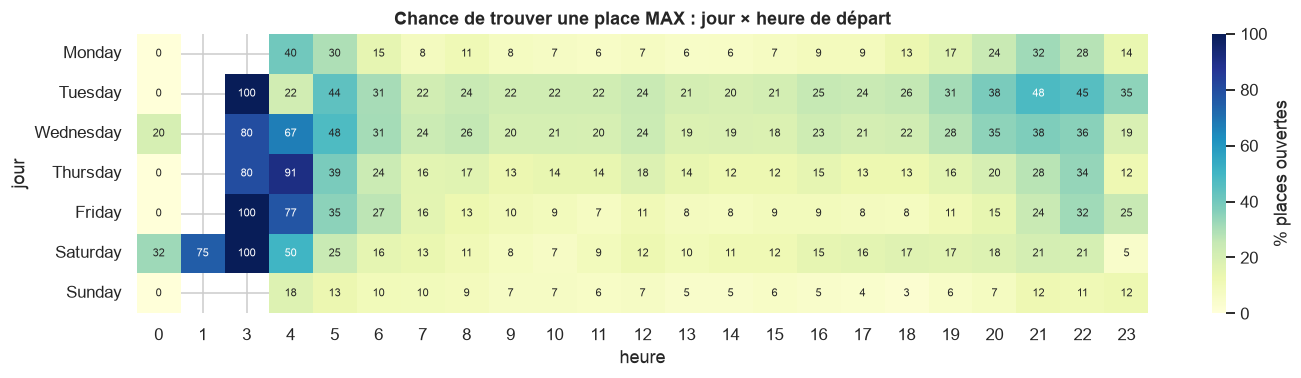

Graphe : 308 gares, 4040 liaisons orientées


,pagerank,degré
PARIS (intramuros),0.1019,488
LYON (intramuros),0.0285,149
MARSEILLE ST CHARLES,0.0154,122
BORDEAUX ST JEAN,0.0152,95
STRASBOURG,0.0141,125
NANTES,0.0127,84
RENNES,0.0125,73
VALENCE TGV AUVERGNE RHONE ALPES,0.0122,108
MEUSE TGV,0.0120,82
ST PIERRE DES CORPS,0.0115,76


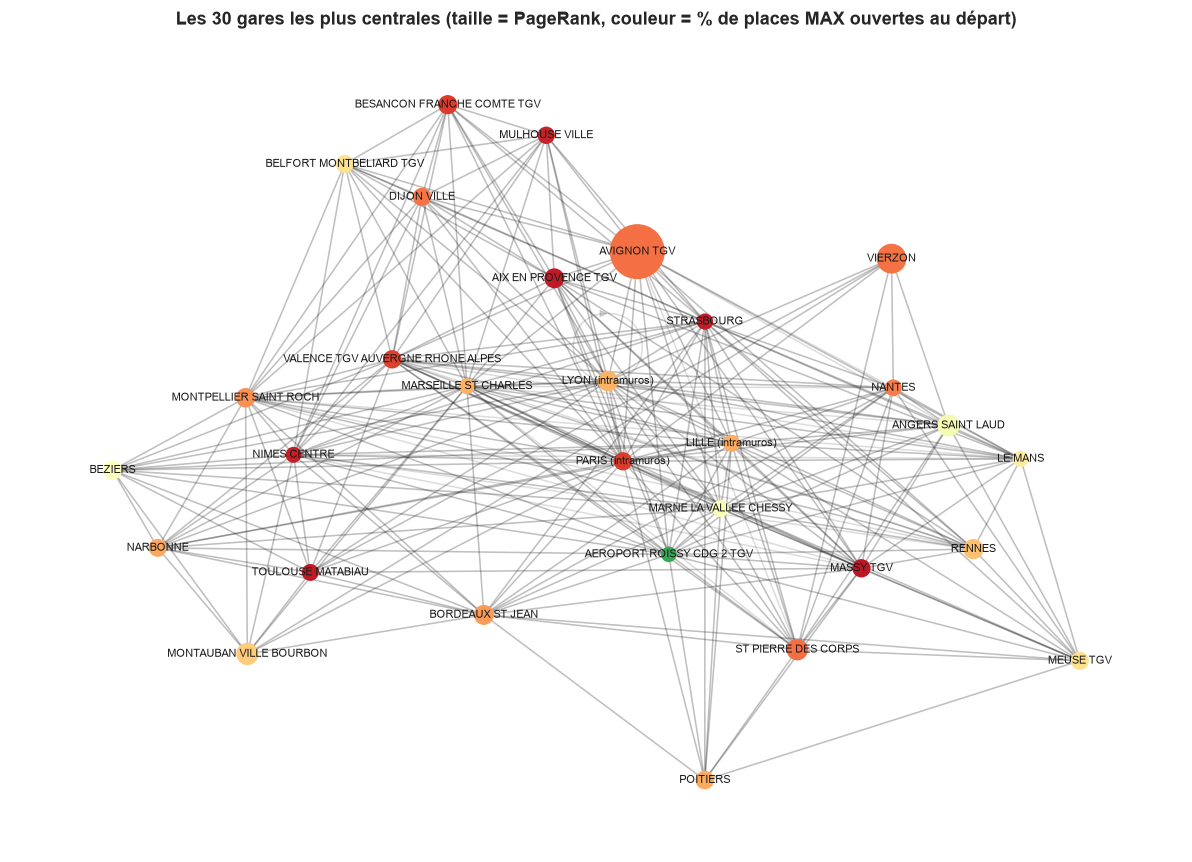

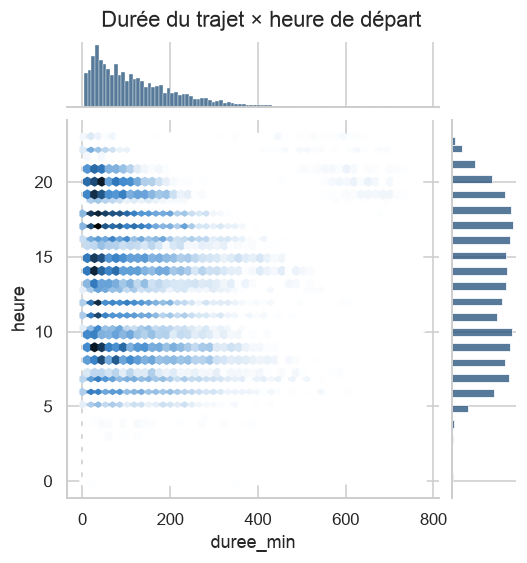

In [59]:
if TGV is not None:
    t = TGV
    # Heatmap jour × heure : quand a-t-on le plus de chance ?
    pv = t.pivot_table(index="jour", columns="heure", values="dispo", aggfunc="mean").reindex(
        ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]) * 100
    fig, ax = plt.subplots(figsize=(13, 3.6))
    sns.heatmap(pv, cmap="YlGnBu", annot=True, fmt=".0f", ax=ax, cbar_kws={"label": "% places ouvertes"}, annot_kws={"size": 7})
    ax.set_title("Chance de trouver une place MAX : jour × heure de départ"); plt.tight_layout(); plt.show()

    # Réseau origine → destination
    import networkx as nx
    od = t.groupby(["Origine", "Destination"]).agg(trains=("dispo", "size"), dispo=("dispo", "mean")).reset_index()
    G = nx.from_pandas_edgelist(od, "Origine", "Destination", ["trains", "dispo"], create_using=nx.DiGraph)
    pr = pd.Series(nx.pagerank(G, weight="trains")).sort_values(ascending=False)
    deg = pd.Series(dict(G.degree()))
    hub = pd.DataFrame({"pagerank": pr, "degré": deg}).sort_values("pagerank", ascending=False)
    print(f"Graphe : {G.number_of_nodes()} gares, {G.number_of_edges()} liaisons orientées")
    display(hub.head(12).round(4))

    top = pr.head(30).index
    H = G.subgraph(top)
    pos = nx.spring_layout(H, seed=SEED, k=.9, weight="trains")
    fig, ax = plt.subplots(figsize=(11, 8))
    nx.draw_networkx_edges(H, pos, alpha=.15, arrows=False, ax=ax)
    nx.draw_networkx_nodes(H, pos, node_size=pr[top] * 12000, node_color=[od[(od.Origine == n)].dispo.mean() for n in top],
                           cmap="RdYlGn", ax=ax, vmin=0, vmax=.5)
    nx.draw_networkx_labels(H, pos, font_size=7, ax=ax); ax.axis("off")
    ax.set_title("Les 30 gares les plus centrales (taille = PageRank, couleur = % de places MAX ouvertes au départ)")
    plt.tight_layout(); plt.show()

    # Plus c'est long, plus c'est ouvert ?
    sns.jointplot(data=t.dropna(subset=["duree_min"]).sample(min(len(t), 30_000), random_state=SEED),
                  x="duree_min", y="heure", kind="hex", height=5, color="#1f4e79")
    plt.suptitle("Durée du trajet × heure de départ", y=1.02); plt.show()

## 8. GTFS SNCF, horaires des gares, accessibilité

### 8.1 GTFS : le pouls du réseau

stop_times chargés : 500 000 (échantillon)
Horaires ≥ 24h : 0.57% (valides en GTFS, pièges classiques pour un parseur datetime)


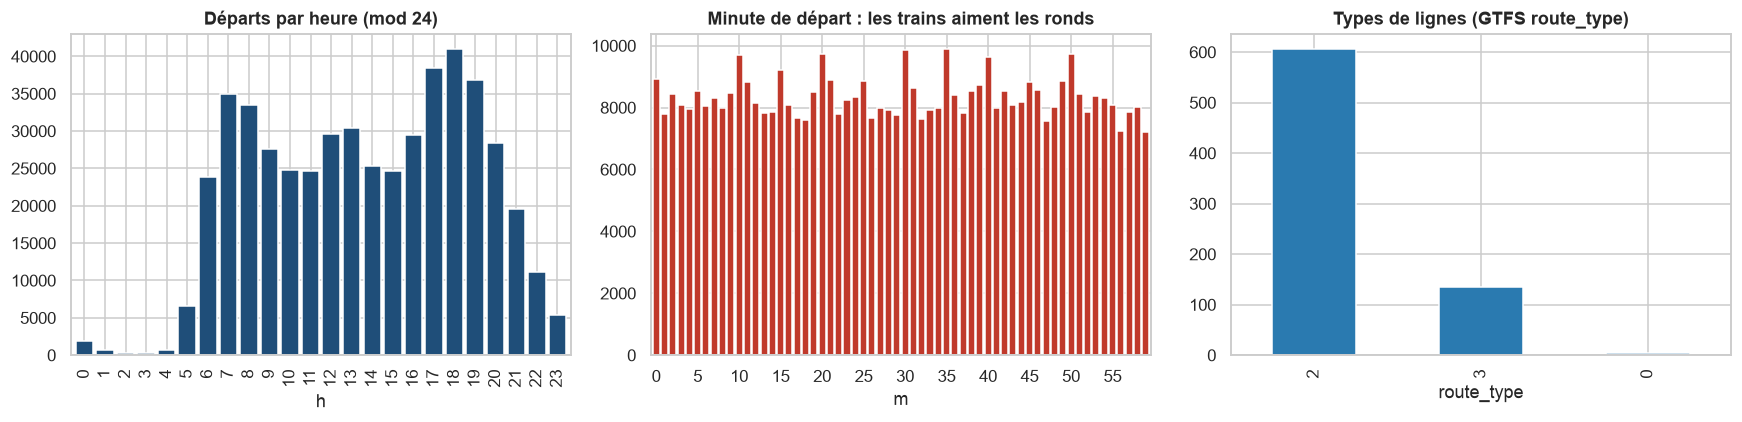

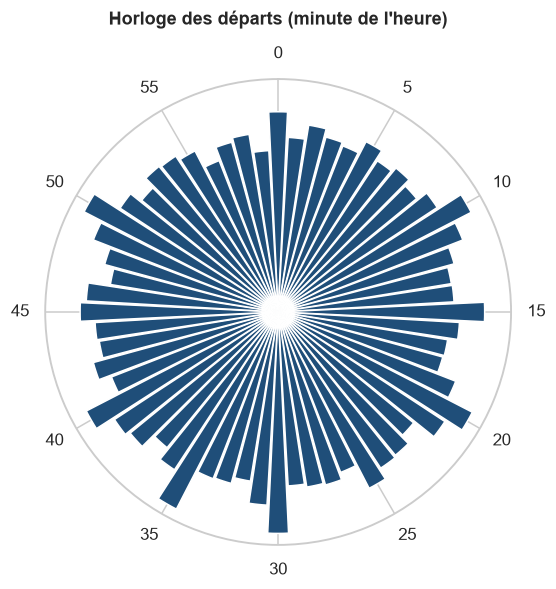

,route_long_name,route_short_name,voyages
route_id,,,
FR:Line::0c436faa-ccd8-4cb5-9b79-1c8a701364c4:,Grasse - Cannes - Nice - Vintimille,C3,820
FR:Line::9302e13e-8434-45ce-a5bc-9fe445fd95bc:,PARIS - MULHOUSE,K4,584
FR:Line::6831fb72-94d3-417c-915f-b9656db78b1a:,41+. Libourne - Bordeaux - Arcachon,F41+,575
FR:Line::96809d68-f37d-4e68-ac3c-3c0540f4e2f2:,Les Arcs - Cannes - Nice - Menton,C13,560
FR:Line::B10C45A0-C32C-4232-85F2-4BB81B810084:,Paris - Lyon P D,K7,549
FR:Line::A6C76228-9224-4C48-8B92-80FC80F093E2:,Lille - Mediterranee TGV,001B,521
FR:Line::BAF1DE9A-72EC-4064-8BE9-C4EFF292CB6A:,Paris - Marseille - Toulon TGV,631B,452
FR:Line::6c285671-9f9c-44db-80ac-068653b4e95a:,Remiremont - Luxembourg et Lunéville - Luxembourg,C40+,431
FR:Line::0128E1D5-9183-4D58-B1CF-F5AA5A64A037:,Marseille - Toulon - Hyeres,C6,419


In [60]:
if not absent("gtfs/stop_times", "gtfs/routes", "gtfs/trips"):
    st, routes, trips = find("gtfs/stop_times"), find("gtfs/routes"), find("gtfs/trips")
    print("stop_times chargés :", f"{len(st):,}".replace(",", " "),
          "(échantillon)" if CATALOGUE.loc[[k for k in DF if "gtfs/stop_times" in k][0], "echantillon"] else "")

    # Horaires GTFS : l'heure peut dépasser 24:00:00 (service de nuit rattaché au jour précédent)
    dep = st.departure_time.dropna().astype(str).str.extract(r"(\d+):(\d+):(\d+)").astype(int)
    dep.columns = ["h", "m", "s"]
    print(f"Horaires ≥ 24h : {100 * (dep.h >= 24).mean():.2f}% (valides en GTFS, pièges classiques pour un parseur datetime)")

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    dep.h.mod(24).value_counts().sort_index().plot(kind="bar", ax=axes[0], color="#1f4e79", width=.85)
    axes[0].set_title("Départs par heure (mod 24)")
    dep.m.value_counts().sort_index().plot(kind="bar", ax=axes[1], color="#c0392b", width=.85)
    axes[1].set_title("Minute de départ : les trains aiment les ronds"); axes[1].set_xticks(range(0, 60, 5))
    axes[1].set_xticklabels(range(0, 60, 5), rotation=0)
    rt = routes.route_type.value_counts() if "route_type" in routes else pd.Series(dtype=int)
    rt.plot(kind="bar", ax=axes[2], color="#2a7ab0"); axes[2].set_title("Types de lignes (GTFS route_type)")
    plt.tight_layout(); plt.show()

    # Horloge polaire des minutes (poésie du cadencement)
    cnt = dep.m.value_counts().reindex(range(60), fill_value=0)
    ang = np.linspace(0, 2 * np.pi, 60, endpoint=False)
    fig = plt.figure(figsize=(5.5, 5.5)); ax = fig.add_subplot(111, projection="polar")
    ax.bar(ang, cnt.values, width=2 * np.pi / 60 * .9, color="#1f4e79"); ax.set_theta_zero_location("N"); ax.set_theta_direction(-1)
    ax.set_xticks(ang[::5]); ax.set_xticklabels(range(0, 60, 5)); ax.set_yticks([])
    ax.set_title("Horloge des départs (minute de l'heure)", pad=14); plt.show()

    # Lignes les plus chargées
    tpr = trips.groupby("route_id").size().rename("voyages")
    r = routes.set_index("route_id")[[c for c in ["route_long_name", "route_short_name"] if c in routes]].join(tpr).sort_values("voyages", ascending=False)
    display(r.head(12))

Familles d'identifiants d'arrêts :


,arrêts
stop_id,
StopArea:OCE,3435
StopPoint:OCETrain TER,2493
StopPoint:OCECar TER,2314
StopPoint:OCETGV INOUI,191
StopPoint:OCEINTERCITES,89
StopPoint:OCEINTERCITES de nuit,87
StopPoint:OCEOUIGO,83
StopPoint:OCECar à réservation,45
StopPoint:OCEICE,33


location_type (0 = arrêt, 1 = gare mère) : {0: 5394, 1: 3435}


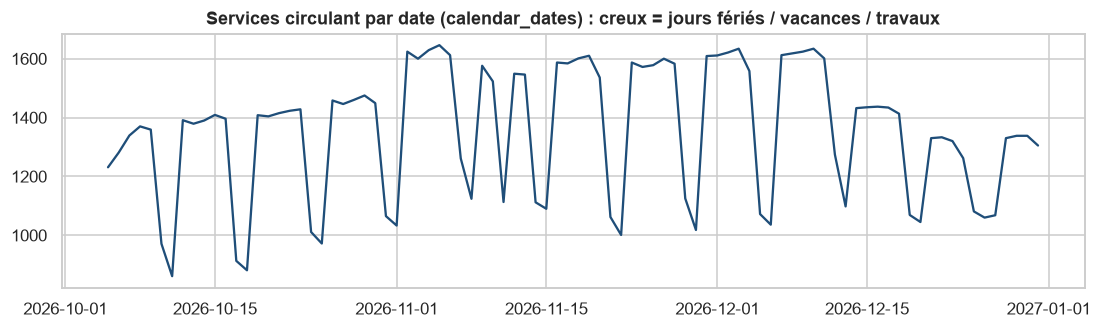

In [61]:
if not absent("gtfs/stops"):
    stops = find("gtfs/stops")
    # Les identifiants d'arrêts encodent leur réseau : on lit la « famille » dans le préfixe
    fam = stops.stop_id.astype(str).str.replace(r"[-:]?\d+.*$", "", regex=True).str[:40]
    print("Familles d'identifiants d'arrêts :")
    display(fam.value_counts().head(10).to_frame("arrêts"))
    if "location_type" in stops:
        print("location_type (0 = arrêt, 1 = gare mère) :", stops.location_type.value_counts().to_dict())

if not absent("gtfs/calendar_dates"):
    cd = find("gtfs/calendar_dates").copy()
    cd["d"] = pd.to_datetime(cd["date"].astype(str), format="%Y%m%d", errors="coerce")
    s = cd.groupby("d").size()
    fig, ax = plt.subplots(figsize=(12, 3)); ax.plot(s.index, s.values, color="#1f4e79")
    ax.set_title("Services circulant par date (calendar_dates) : creux = jours fériés / vacances / travaux"); plt.show()

### 8.2 Horaires d'ouverture des gares

Non analysables (jour normal) : {}


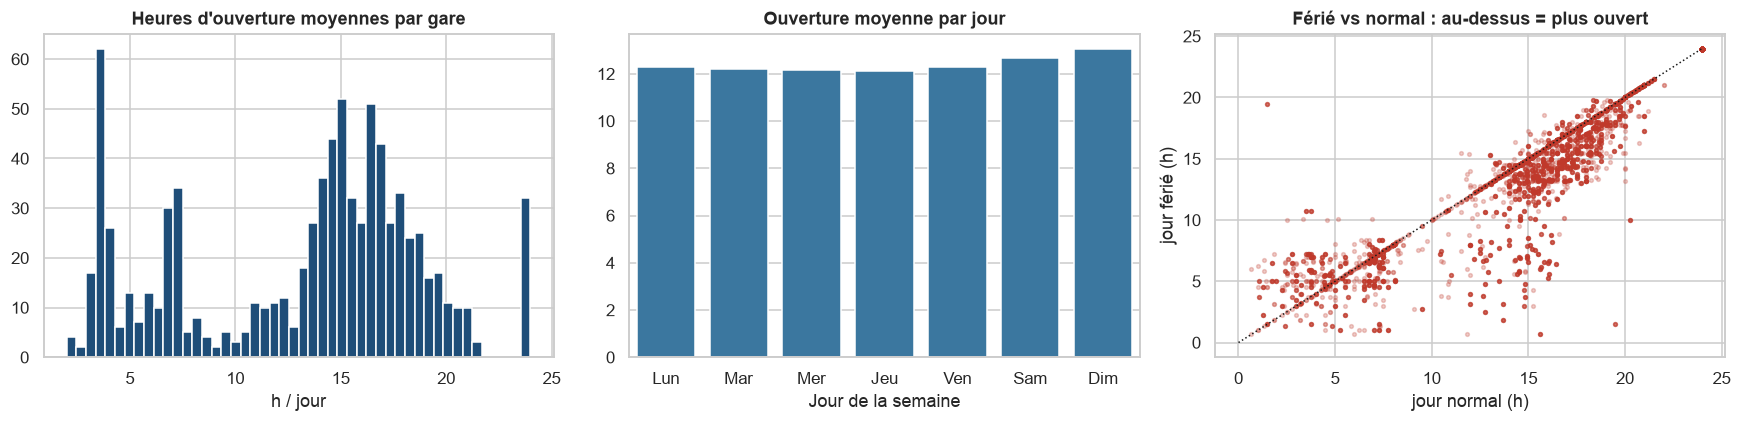

Gares ouvertes 24h/24 : 32 sur 844
Créneaux qui se terminent à 22h ou avant : 87%


In [62]:
if not absent("horaires_gares"):
    h = find("horaires_gares").copy()
    RE_H = r"(\d{1,2}):(\d{2})-(\d{1,2}):(\d{2})"

    def minutes_open(s):
        e = s.astype(str).str.extract(RE_H).astype(float)
        return ((e[2] * 60 + e[3]) - (e[0] * 60 + e[1])) % (24 * 60)

    h["ouverture_h"] = minutes_open(h["Horaire en jour normal"]) / 60
    h["ouverture_ferie_h"] = minutes_open(h["Horaire en jour férié"]) / 60
    print("Non analysables (jour normal) :", h["Horaire en jour normal"][h.ouverture_h.isna()].value_counts().head(5).to_dict())
    h.loc[h["Horaire en jour normal"].astype(str).str.startswith("00:00-23:59"), "ouverture_h"] = 24

    par_gare = h.groupby("Gare").ouverture_h.mean()
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    axes[0].hist(par_gare.dropna(), bins=48, color="#1f4e79"); axes[0].set_title("Heures d'ouverture moyennes par gare"); axes[0].set_xlabel("h / jour")
    ordre = ["Lundi", "Mardi", "Mercredi", "Jeudi", "Vendredi", "Samedi", "Dimanche"]
    j = h.groupby("Jour de la semaine").ouverture_h.mean().reindex(ordre)
    sns.barplot(x=j.index.str[:3], y=j.values, ax=axes[1], color="#2a7ab0"); axes[1].set_title("Ouverture moyenne par jour")
    axes[2].scatter(h.ouverture_h, h.ouverture_ferie_h, s=6, alpha=.25, color="#c0392b"); axes[2].plot([0, 24], [0, 24], "k:", lw=1)
    axes[2].set_xlabel("jour normal (h)"); axes[2].set_ylabel("jour férié (h)"); axes[2].set_title("Férié vs normal : au-dessus = plus ouvert")
    plt.tight_layout(); plt.show()

    print(f"Gares ouvertes 24h/24 : {int((par_gare >= 23.9).sum())} sur {len(par_gare)}")
    fin = h["Horaire en jour normal"].astype(str).str.extract(r"-(\d{1,2}):")[0].astype(float)
    print(f"Créneaux qui se terminent à 22h ou avant : {100 * (fin <= 22).mean():.0f}%")

### 8.3 Accessibilité des gares (NeTEx / XML)

2 798 lieux d'arrêt NeTEx · colonnes : ['nom', 'lat', 'lon', 'mobilite_reduite', 'WheelchairAccess', 'StepFreeAccess', 'EscalatorFreeAccess', 'LiftFreeAccess', 'AudibleSignalsAvailable', 'VisualSignsAvailable', 'TactileGuidanceAvailable']


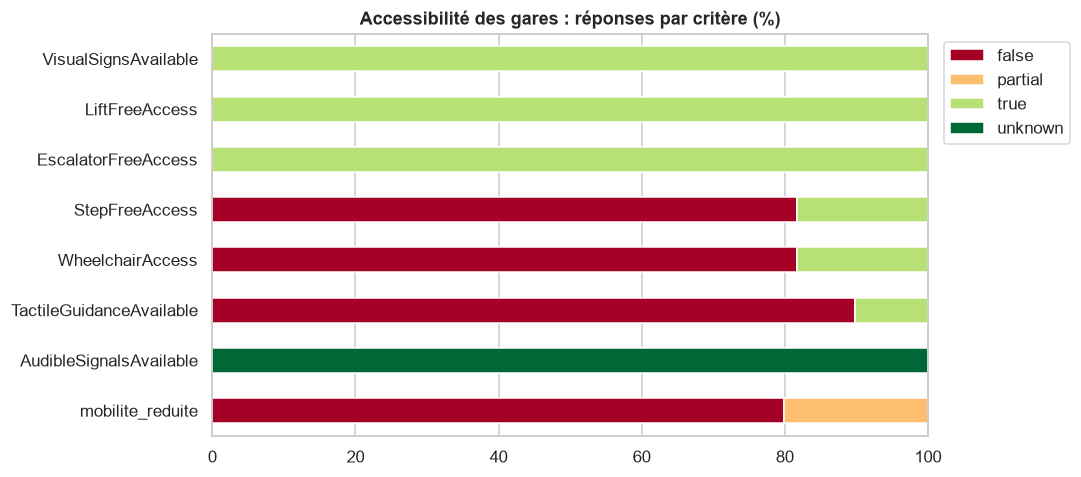

In [63]:
ACC = None
xml_files = list((DATA_DIR / "pieton_accessibilite_gares").glob("*.xml")) if (DATA_DIR / "pieton_accessibilite_gares").is_dir() else []
if xml_files:
    NS = "{http://www.netex.org.uk/netex}"
    recs = []
    for _, el in ET.iterparse(xml_files[0], events=("end",)):
        if el.tag == NS + "StopPlace":
            loc = el.find(f"{NS}Centroid/{NS}Location")
            rec = dict(nom=el.findtext(f"{NS}Name"),
                       lat=float(loc.findtext(f"{NS}Latitude")) if loc is not None and loc.findtext(f"{NS}Latitude") else np.nan,
                       lon=float(loc.findtext(f"{NS}Longitude")) if loc is not None and loc.findtext(f"{NS}Longitude") else np.nan,
                       mobilite_reduite=el.findtext(f"{NS}AccessibilityAssessment/{NS}MobilityImpairedAccess"))
            lim = el.find(f".//{NS}AccessibilityLimitation")
            if lim is not None:
                for child in lim:
                    rec[child.tag.replace(NS, "")] = child.text
            recs.append(rec)
            el.clear()
    ACC = pd.DataFrame(recs)
    print(f"{len(ACC):,} lieux d'arrêt NeTEx".replace(",", " "), "· colonnes :", list(ACC.columns))
    bools = [c for c in ACC.columns if c not in {"nom", "lat", "lon"}]
    tab = pd.DataFrame({c: ACC[c].value_counts(normalize=True) for c in bools}).T.fillna(0) * 100
    ax = tab.sort_values("true" if "true" in tab else tab.columns[0]).plot(kind="barh", stacked=True, figsize=(10, 4.5), colormap="RdYlGn")
    ax.set_title("Accessibilité des gares : réponses par critère (%)"); ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left"); plt.tight_layout(); plt.show()
    GEO["accessibilité"] = ACC[["lat", "lon"]].assign(dec=raw_decimals(ACC.lat))
else:
    print("Pas de fichier XML d'accessibilité — ajouter pieton_accessibilite_gares dans SOURCES.")

## 9. Festivals, INSEE, fraîcheur des données

Festivals : (7283, 30) — colonnes clés : ['Envergure territoriale', 'Région principale de déroulement', 'Décennie de création du festival', 'Année de création du festival', 'Discipline dominante']
Années de création les plus fréquentes : {2015.0: 347, 2016.0: 320, 2017.0: 316, 2018.0: 278, 2011.0: 249}


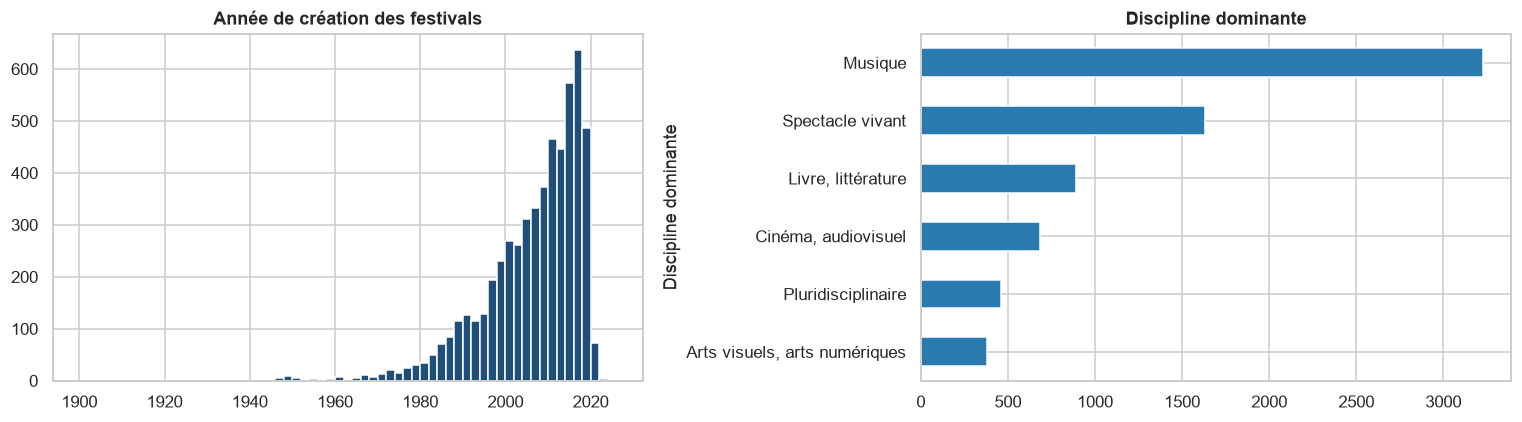

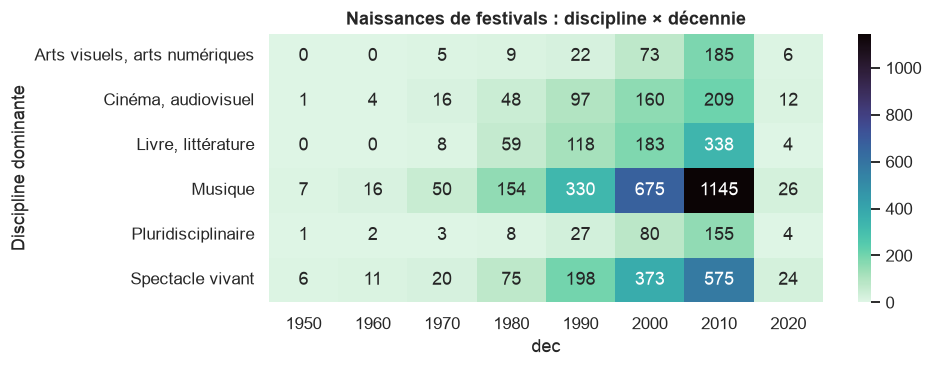

In [64]:
if not absent("festivals"):
    f = find("festivals")
    print("Festivals :", f.shape, "— colonnes clés :", [c for c in f.columns if re.search("création|discipline|envergure|région", c, re.I)][:8])
    ycol = next((c for c in f.columns if re.search(r"Année de création", c)), None)
    dcol = next((c for c in f.columns if re.search(r"Discipline dominante", c)), None)
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    if ycol:
        y = pd.to_numeric(f[ycol], errors="coerce").dropna(); y = y[(y > 1900) & (y <= 2026)]
        axes[0].hist(y, bins=range(1900, 2028, 2), color="#1f4e79"); axes[0].set_title("Année de création des festivals")
        pics = y.value_counts().head(5)
        print("Années de création les plus fréquentes :", pics.to_dict())
    if dcol:
        f[dcol].value_counts().head(12).sort_values().plot(kind="barh", ax=axes[1], color="#2a7ab0"); axes[1].set_title("Discipline dominante")
    plt.tight_layout(); plt.show()
    if ycol and dcol:
        f2 = f.assign(y=pd.to_numeric(f[ycol], errors="coerce"))
        f2 = f2[f2.y.between(1950, 2026) & f2[dcol].isin(f[dcol].value_counts().head(6).index)]
        pv = f2.assign(dec=(f2.y // 10 * 10).astype(int)).pivot_table(index=dcol, columns="dec", values=ycol, aggfunc="size", fill_value=0)
        fig, ax = plt.subplots(figsize=(9, 3.5)); sns.heatmap(pv, annot=True, fmt="d", cmap="mako_r", ax=ax)
        ax.set_title("Naissances de festivals : discipline × décennie"); plt.tight_layout(); plt.show()


— ACTIVITY


,lignes,libellé
ACTIVITY,,
I553,259729,Terrains de camping et parcs pour caravanes ou véhicules de loisirs
I551,129342,Hôtels et hébergement similaire
I552,27835,Hébergement touristique et autre hébergement de courte durée
I552B,27756,Résidences de tourisme – Résidences hôtelières
I552A,27609,Villages vacances et maisons familiales
I552C,27515,Auberges de jeunesse et centres sportifs



— TOUR_MEASURE


,lignes,libellé
TOUR_MEASURE,,
PLACE,296598,Nombre de places
UNIT_LOC,166279,Nombre d’établissements
BEDPLACE,36909,Nombre de place-lits



— UNIT_LOC_RANKING


...


— L_STAY


,lignes,libellé
L_STAY,,
_T,370202,Total
SHORT,64844,De passage
LONG,64740,A l’année



— GEO_OBJECT


,lignes,libellé
GEO_OBJECT,,
COM,417305,Commune
UU2020,29320,Unité urbaine 2020
BV2022,20372,Bassin de vie 2022
EPCI,14892,Etablissement public de coopération intercommunal
AAV2020,8338,Aire d'attraction des villes 2020
ARR,3978,Arrondissement
ZE2020,3630,Zones d'emploi 2020
DEP,1195,Département



Observations non numériques : 0 · OBS_STATUS : {'A': 499786}


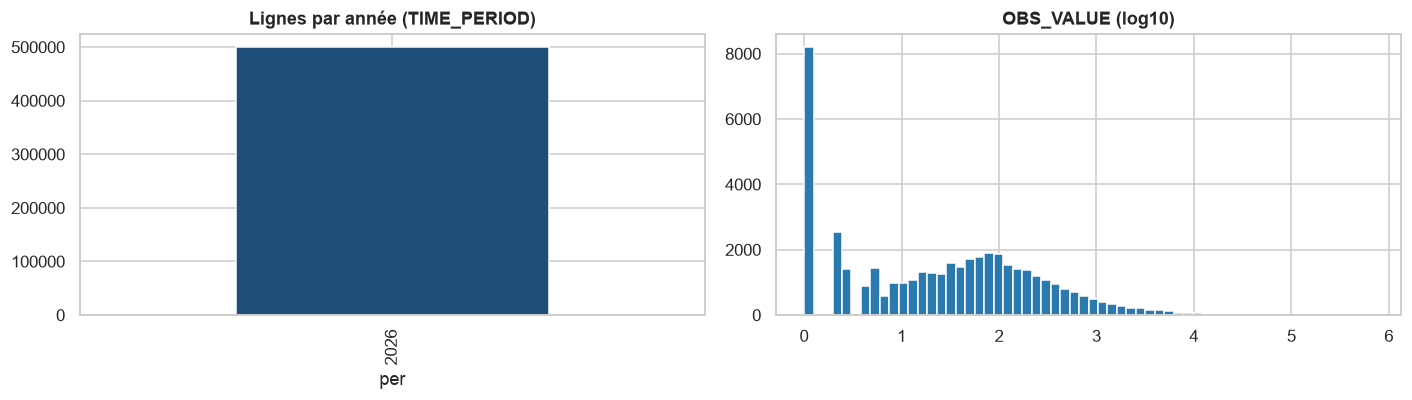

In [65]:
if not absent("insee_tour_cap/DS_TOUR_CAP_2026_data", "insee_tour_cap/DS_TOUR_CAP_2026_metadata"):
    d, m = find("insee_tour_cap/DS_TOUR_CAP_2026_data"), find("insee_tour_cap/DS_TOUR_CAP_2026_metadata")
    # Les modalités sont codées : on les traduit avec le fichier de métadonnées
    lib = m.drop_duplicates(["COD_VAR", "COD_MOD"]).set_index(["COD_VAR", "COD_MOD"]).LIB_MOD
    for var in ["ACTIVITY", "TOUR_MEASURE", "UNIT_LOC_RANKING", "L_STAY", "GEO_OBJECT"]:
        if var in d:
            vc = d[var].value_counts().head(8).to_frame("lignes")
            vc["libellé"] = [lib.get((var, c), "?") for c in vc.index]
            print(f"\n— {var}"); display(vc)
    d = d.assign(obs=pd.to_numeric(d.OBS_VALUE, errors="coerce"), per=d.TIME_PERIOD.astype(str).str[:4])
    print("\nObservations non numériques :", d.obs.isna().sum(), "· OBS_STATUS :", d.OBS_STATUS.value_counts().to_dict())
    fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))
    d.per.value_counts().sort_index().plot(kind="bar", ax=axes[0], color="#1f4e79"); axes[0].set_title("Lignes par année (TIME_PERIOD)")
    axes[1].hist(np.log10(d.obs[d.obs > 0]), bins=60, color="#2a7ab0"); axes[1].set_title("OBS_VALUE (log10)")
    plt.tight_layout(); plt.show()

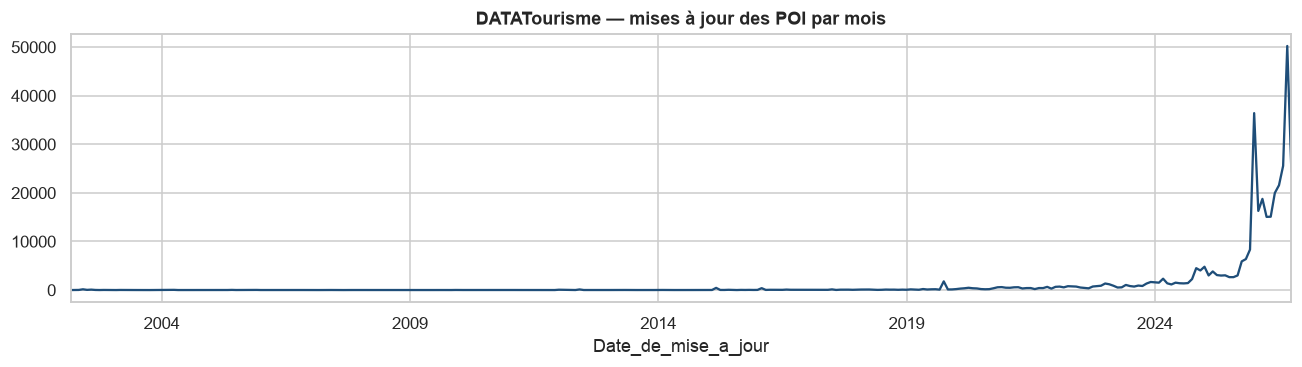

Âge médian de la donnée : 197 jours · plus de 2 ans : 15%


In [66]:
# Fraîcheur : DATATourisme (date de mise à jour de chaque POI)
if not absent("datatourisme_place"):
    dt = find("datatourisme_place")
    if "Date_de_mise_a_jour" in dt:
        u = pd.to_datetime(dt.Date_de_mise_a_jour, errors="coerce", utc=True).dt.tz_localize(None).dropna()
        fig, ax = plt.subplots(figsize=(12, 3.5))
        u.dt.to_period("M").value_counts().sort_index().plot(ax=ax, color="#1f4e79")
        ax.set_title("DATATourisme — mises à jour des POI par mois"); plt.tight_layout(); plt.show()
        age = (pd.Timestamp("2026-10-06") - u).dt.days
        print(f"Âge médian de la donnée : {age.median():.0f} jours · plus de 2 ans : {100 * (age > 730).mean():.0f}%")

---
# 10. Laboratoire — techniques décalées

Ici on teste des idées qui ne servent pas forcément un objectif précis : elles peuvent ne rien dire, ou révéler un défaut
de données qu'aucun rapport classique n'aurait montré. Chaque sous-section indique **ce qu'on espère y voir**.

### 10.1 Loi de Benford — les chiffres sont-ils naturels ?
*Hypothèse :* les quantités « naturelles » (jauges, populations, surfaces) suivent Benford (1 en tête ≈ 30 %).
Un écart marqué trahit des valeurs plafonnées, saisies à la main, imputées ou arrondies.

,série,n,MAD,verdict
0,AGRÉGAT · passages par arrêt GTFS,5189,0.009837,acceptable
1,AGRÉGAT · POI DATATourisme par commune,28424,0.014472,limite
2,AGRÉGAT · voyages par ligne GTFS,744,0.018126,NON conforme
3,DS_TOUR_CAP_2026_data · OBS_VALUE,44560,0.021619,NON conforme
4,AGRÉGAT · trajets TGVmax par gare d'origine,308,0.031920,NON conforme
5,base-des-lieux-et-des-equipeme · Nombre_fauteuils_de_cinema,2081,0.033329,NON conforme
6,velib-disponibilite-en-temps-r · Nombre bornettes libres,1491,0.040141,NON conforme
7,AGRÉGAT · sites Basilic par commune,22084,0.051241,NON conforme


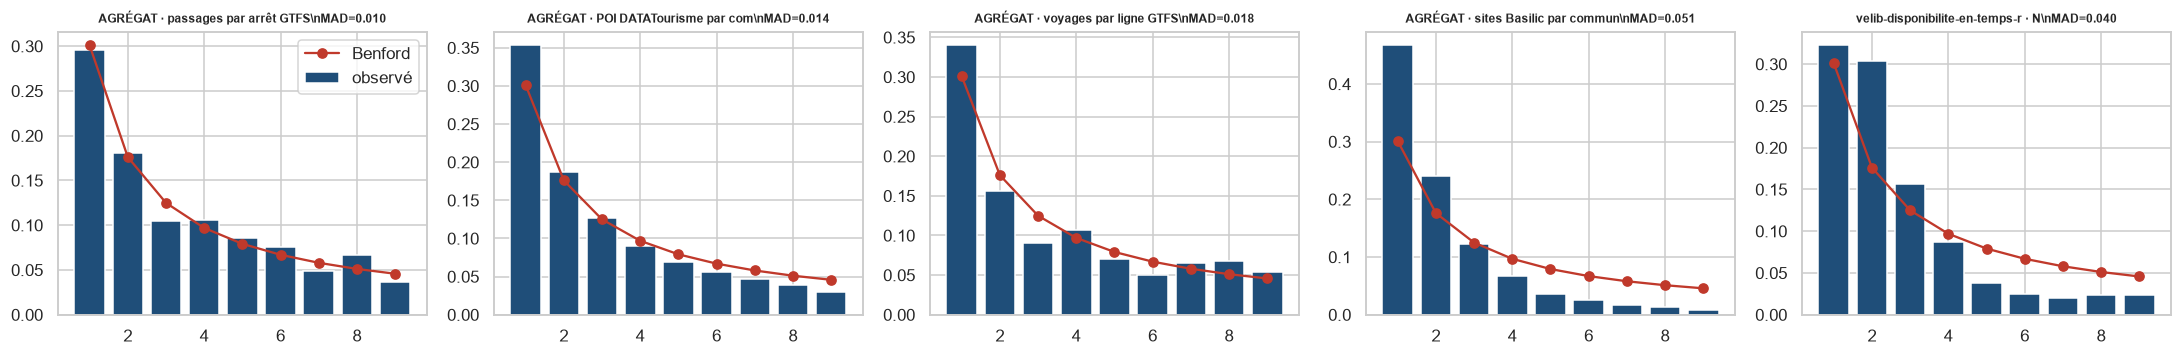

In [67]:
BENFORD = np.log10(1 + 1 / np.arange(1, 10))

def benford_test(x, min_n=200, min_span=100):
    x = pd.to_numeric(x, errors="coerce").dropna()
    x = x[x > 0]
    if len(x) < min_n or x.max() / x.min() < min_span:    # Benford exige plusieurs ordres de grandeur
        return None
    lead = np.floor(x / 10 ** np.floor(np.log10(x))).astype(int)
    obs = lead.value_counts(normalize=True).reindex(range(1, 10), fill_value=0).values
    return dict(n=len(x), MAD=float(np.mean(np.abs(obs - BENFORD))), obs=obs)

# Candidats : colonnes numériques « brutes » + quantités NATURELLES construites par agrégation
# (nombre de sites par commune, d'arrêts, de voyages par ligne…) — là où Benford a le plus de chances de s'appliquer.
cands = {}
for k, df in DF.items():
    ps = PROF[k].set_index("colonne").sémantique
    for c in df.select_dtypes("number").columns:
        if ps.get(c) == "numérique":
            cands[f"{k.split('/')[-1][:30]} · {c}"] = df[c]
if (b := find("basilic")) is not None:
    cands["AGRÉGAT · sites Basilic par commune"] = b.groupby("code_insee").size()
if (dtm := find("datatourisme_place")) is not None and "Code_postal_et_commune" in dtm:
    cands["AGRÉGAT · POI DATATourisme par commune"] = dtm.Code_postal_et_commune.value_counts()
if (st := find("gtfs/stop_times")) is not None:
    cands["AGRÉGAT · passages par arrêt GTFS"] = st.stop_id.value_counts()
if (tr := find("gtfs/trips")) is not None:
    cands["AGRÉGAT · voyages par ligne GTFS"] = tr.route_id.value_counts()
if TGV is not None:
    cands["AGRÉGAT · trajets TGVmax par gare d'origine"] = TGV.Origine.value_counts()
if (cd := find("gtfs/calendar_dates")) is not None:
    cands["AGRÉGAT · services par date GTFS"] = cd.groupby("date").size()

res = []
for name, ser in cands.items():
    r = benford_test(ser)
    if r:
        res.append(dict(série=name, **r))
BEN = pd.DataFrame(res)
if BEN.empty:
    print("Aucune série ne remplit les conditions de Benford.")
else:
    # seuils de Nigrini : <0,006 conforme · <0,012 acceptable · <0,015 limite · sinon non conforme
    BEN["verdict"] = pd.cut(BEN.MAD, [0, .006, .012, .015, 1], labels=["conforme", "acceptable", "limite", "NON conforme"])
    display(BEN.drop(columns="obs").sort_values("MAD").reset_index(drop=True))
    sel = pd.concat([BEN.nsmallest(3, "MAD"), BEN.nlargest(2, "MAD")]).drop_duplicates("série")
    fig, axes = plt.subplots(1, len(sel), figsize=(4.0 * len(sel), 3.4), squeeze=False)
    for ax, (_, r) in zip(axes[0], sel.iterrows()):
        ax.bar(range(1, 10), r.obs, color="#1f4e79", label="observé"); ax.plot(range(1, 10), BENFORD, "o-", color="#c0392b", label="Benford")
        ax.set_title(f"{r['série'][:34]}\\nMAD={r.MAD:.3f}", fontsize=8)
    axes[0][0].legend(); plt.tight_layout(); plt.show()

### 10.2 Préférence pour certains chiffres (arrondis, « heaping »)
*Hypothèse :* si des humains saisissent les valeurs, les entiers finissent par 0 ou 5 bien plus que les 20 % attendus.
Même test sur les minutes d'horaires (`:00`, `:15`, `:30`).

In [68]:
res = []
for k, df in DF.items():
    for c in df.select_dtypes("number").columns:
        x = pd.to_numeric(df[c], errors="coerce").dropna()
        x = x[x != 0]                                     # les zéros (absence) finissent toujours par 0 : on les écarte
        if len(x) < 1000 or not np.allclose(x, x.round()) or x.nunique() < 30:
            continue
        if PROF[k].set_index("colonne").sémantique.get(c) != "numérique":
            continue
        last = (x.abs().astype(np.int64) % 10).value_counts(normalize=True).reindex(range(10), fill_value=0)
        res.append(dict(table=k, colonne=c, n=len(x), fin_par_0_ou_5_pct=round(100 * (last[0] + last[5]), 1)))
HEAP = pd.DataFrame(res).sort_values("fin_par_0_ou_5_pct", ascending=False)
print("Attendu sous hasard : 20 %")
display(HEAP.head(15) if len(HEAP) else "aucune colonne entière numérique assez grande")

Attendu sous hasard : 20 %


,table,colonne,n,fin_par_0_ou_5_pct
8,vls_paris_velib/velib-disponibilite-en-temps-reel,Capacité de la station,1517,28.0
6,basilic/base-des-lieux-et-des-equipements-culturels,Nombre_fauteuils_de_cinema,2081,27.9
3,lignes_par_region/lignes-par-region-administrative,Y_F_L93,2909,20.7
4,horaires_sncf_gtfs/calendar_dates,date,119299,20.1
1,lignes_par_region/lignes-par-region-administrative,Y_D_L93,2909,19.9
9,vls_paris_velib/velib-disponibilite-en-temps-reel,Nombre bornettes libres,1491,19.9
0,lignes_par_region/lignes-par-region-administrative,X_D_L93,2909,19.8
2,lignes_par_region/lignes-par-region-administrative,X_F_L93,2909,19.7
7,insee_tour_cap/DS_TOUR_CAP_2026_data,OBS_VALUE,44560,19.1
10,vls_paris_velib/velib-disponibilite-en-temps-reel,Nombre total vélos disponibles,1389,15.6


### 10.3 Radar de clés de jointure
*Idée :* au lieu de deviner quelles colonnes se joignent, on laisse les **valeurs** parler.
Chaque valeur (normalisée : minuscules, zéros de tête retirés) est indexée ; on compte combien de valeurs deux colonnes de
tables différentes ont en commun. Résultat attendu : le code UIC (zéros de tête !), les codes INSEE, les départements.

In [69]:
def normalize_values(s, cap=50_000):
    s = s.dropna()
    if s.dtype == float:
        if not np.allclose(s, s.round()): return None
        s = s.astype(np.int64)
    v = pd.Series(s.astype(str).str.strip().str.lower().str.replace(r"\.0$", "", regex=True).str.lstrip("0").unique())
    v = v[v.str.len().between(4, 40)]
    return set(v.sample(min(len(v), cap), random_state=SEED)) if len(v) >= 30 else None

col_sets = {}
for k, df in DF.items():
    if k.endswith("metadata"):                              # dictionnaires de codes : redondants avec les tables de données
        continue
    for c in df.columns:
        if PROF[k].set_index("colonne").sémantique.get(c) in {"latitude", "longitude", "texte", "date", "vide", "complexe"}:
            continue
        if df[c].dtype == object or pd.api.types.is_integer_dtype(df[c]) or df[c].dtype == float:
            s = normalize_values(df[c])
            if s: col_sets[(k, c)] = s

index = defaultdict(list)
for key, vals in col_sets.items():
    for v in vals: index[v].append(key)

pairs = Counter()
for v, owners in index.items():
    if 2 <= len(owners) <= 25:
        for a, b in combinations(owners, 2):
            if a[0].split("/")[0] != b[0].split("/")[0]:    # jointures ENTRE sources (pas à l'intérieur d'un GTFS)
                pairs[(a, b)] += 1

rows = []
for (a, b), inter in pairs.items():
    na, nb = len(col_sets[a]), len(col_sets[b])
    rows.append(dict(colonne_A=f"{a[0].split('/')[-1][:24]}.{a[1][:22]}", colonne_B=f"{b[0].split('/')[-1][:24]}.{b[1][:22]}",
                     communes=inter, couverture_min=inter / min(na, nb), jaccard=inter / (na + nb - inter)))
JOIN = pd.DataFrame(rows)
JOIN = JOIN[(JOIN.communes >= 30) & (JOIN.couverture_min >= .2)].sort_values(["couverture_min", "communes"], ascending=False)
print(f"{len(col_sets)} colonnes candidates · {len(JOIN)} paires plausibles")
display(JOIN.head(25).style.format({"couverture_min": "{:.0%}", "jaccard": "{:.0%}"}).background_gradient(subset=["couverture_min"], cmap="Greens"))

26 colonnes candidates · 37 paires plausibles


,colonne_A,colonne_B,communes,couverture_min,jaccard
18,tgvmax.TRAIN_NO,trips.trip_headsign,1285,100%,7%
35,trips.service_id,festivals-global-festiva.identifiant CNM,612,98%,7%
34,trips.service_id,base-des-lieux-et-des-eq.Nombre_fauteuils_de_ci,281,97%,3%
12,gares-de-voyageurs.Code commune,data.code_com,105,97%,4%
52,trips.service_id,festivals-global-festiva.Année de création du f,76,93%,1%
10,trips.service_id,DS_TOUR_CAP_2026_data.OBS_VALUE,1412,87%,16%
13,trips.block_id,data.code_com,93,86%,0%
98,trips.block_id,festivals-global-festiva.Année de création du f,70,85%,0%
4,trips.block_id,velib-disponibilite-en-t.Identifiant station,1286,85%,3%
40,trips.block_id,festivals-global-festiva.identifiant CNM,529,85%,1%


### 10.4 Arbre généalogique des schémas
*Idée :* deux jeux de données qui nomment leurs colonnes avec les mêmes mots (« commune », « région », « date ») sont probablement
produits par la même chaîne de fabrication. On mesure la proximité des vocabulaires de colonnes et on regroupe.

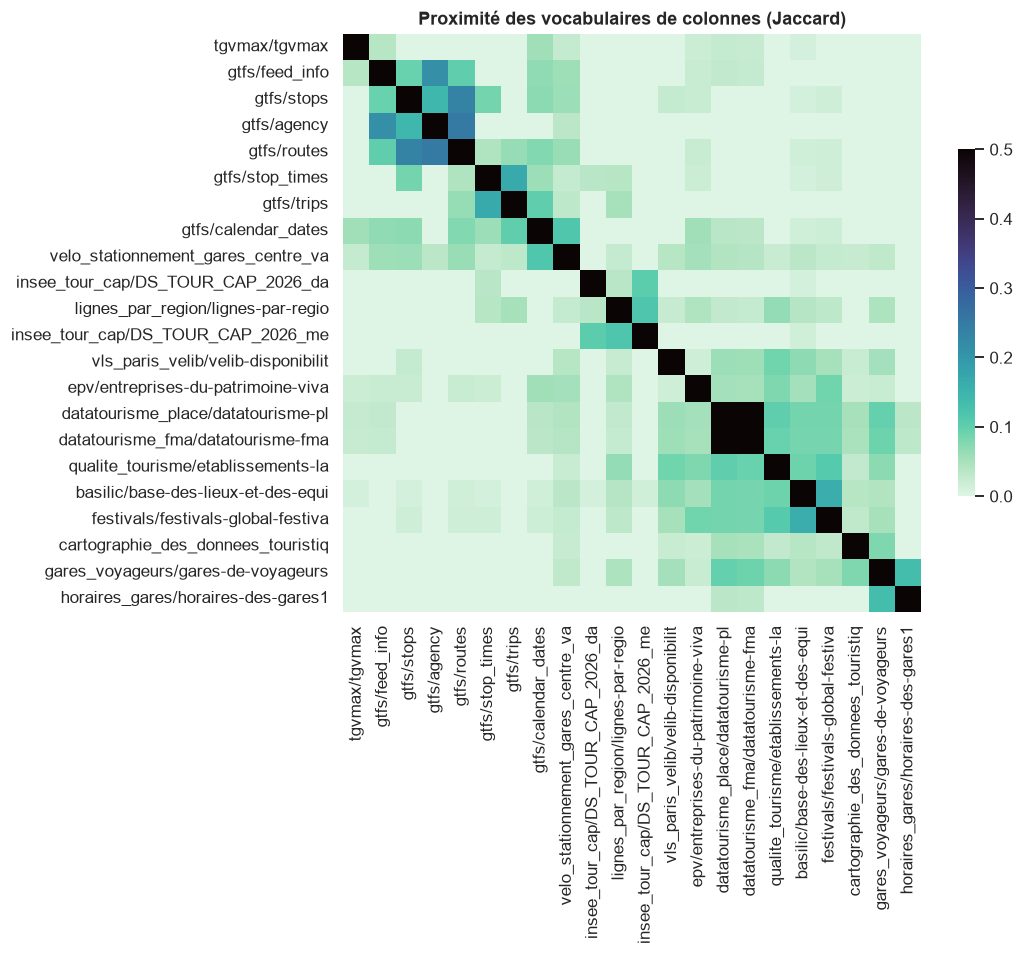

In [70]:
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import squareform

STOP = {"de", "du", "des", "la", "le", "les", "et", "en", "d", "l", "a", "au", "un", "une", "id"}
tokens = {k: {t for c in d.columns for t in norm(c).split() if t not in STOP and len(t) > 2} for k, d in DF.items()}
keys = list(tokens)
S = np.array([[len(tokens[a] & tokens[b]) / max(1, len(tokens[a] | tokens[b])) for b in keys] for a in keys])
order = leaves_list(linkage(squareform(1 - S, checks=False), "average"))
lab = [keys[i].replace("horaires_sncf_gtfs/", "gtfs/")[:34] for i in order]
fig, ax = plt.subplots(figsize=(10, 8.5))
sns.heatmap(S[np.ix_(order, order)], xticklabels=lab, yticklabels=lab, cmap="mako_r", vmin=0, vmax=.5, ax=ax, square=True, cbar_kws={"shrink": .6})
ax.set_title("Proximité des vocabulaires de colonnes (Jaccard)"); plt.tight_layout(); plt.show()

### 10.5 Empreinte des valeurs manquantes
*Idée :* le motif des trous est une signature. Si trois colonnes sont vides **ensemble**, c'est qu'elles appartiennent à un
sous-schéma (ex. « jauge », « écrans », « fauteuils » = cinéma). La corrélation des masques de NaN les regroupe.

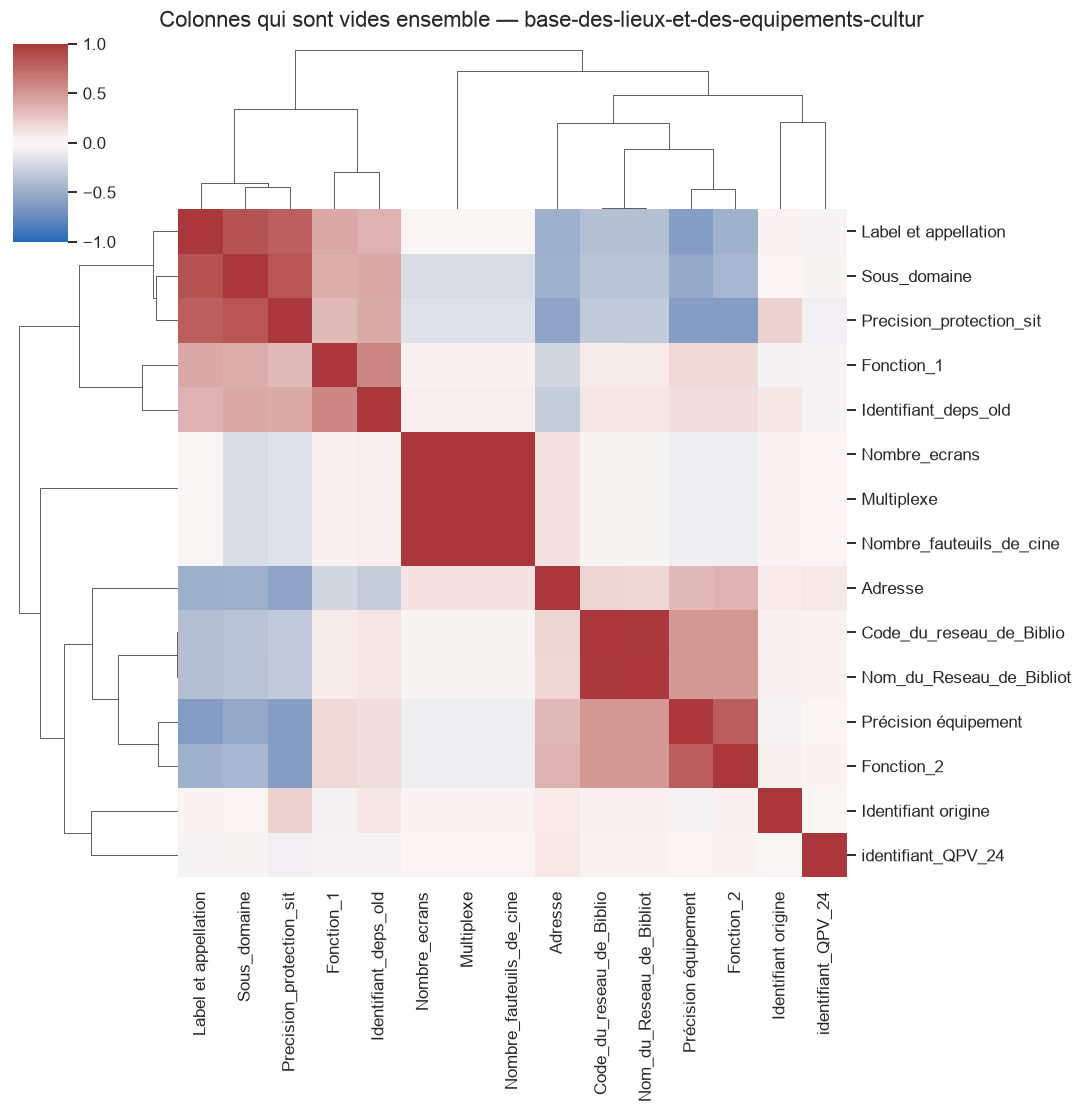

corr. des trous
Multiplexe                      Nombre_ecrans                                   1.000000
                                Nombre_fauteuils_de_cinema                      1.000000
Nombre_fauteuils_de_cinema      Nombre_ecrans                                   1.000000
Code_du_reseau_de_Bibliotheques Nom_du_Reseau_de_Bibliotheques                  0.991365
Label et appellation            Sous_domaine                                    0.864091
Sous_domaine                    Precision_protection_sites_et_monuments         0.844647
Précision équipement            Fonction_2                                      0.811340
Label et appellation            Precision_protection_sites_et_monuments         0.803587
Fonction_1                      Identifiant_deps_old                            0.589387
Précision équipement            Code_du_reseau_de_Bibliotheques                 0.503854
Fonction_2                      Code_du_reseau_de_Bibliotheques                 0.500860
Précision équipement            Nom_du_Reseau_de_Bibliotheques                  0.499503

datatourisme_place/datatourisme-place : pas assez de colonnes partiellement remplies.


In [71]:
def missing_fingerprint(key, top_pairs=12):
    df = DF[key]
    cols = [c for c in df.columns if .02 < df[c].isna().mean() < .98]
    if len(cols) < 4:
        print(f"{key} : pas assez de colonnes partiellement remplies."); return
    cols = cols[:60]
    m = df[cols].isna().astype(int)
    c = m.corr().fillna(0)
    g = sns.clustermap(c, cmap="vlag", center=0, vmin=-1, vmax=1, figsize=(10, 10),
                       xticklabels=[x[:24] for x in cols], yticklabels=[x[:24] for x in cols])
    g.fig.suptitle(f"Colonnes qui sont vides ensemble — {key.split('/')[-1][:40]}", y=1.01); plt.show()
    pr = c.where(np.triu(np.ones(c.shape), 1).astype(bool)).stack().sort_values(ascending=False).head(top_pairs)
    display(pr.rename("corr. des trous").to_frame())

for frag in ["basilic", "datatourisme_place"]:
    k = next((k for k in DF if frag in k), None)
    if k: missing_fingerprint(k)

### 10.6 Zipf — la longue traîne des catégories
*Hypothèse :* types d'équipements, catégories de POI, communes : si le log du rang est linéaire avec le log de la fréquence,
la distribution est « naturelle » et quelques catégories écrasent le reste — utile pour décider quoi regrouper.

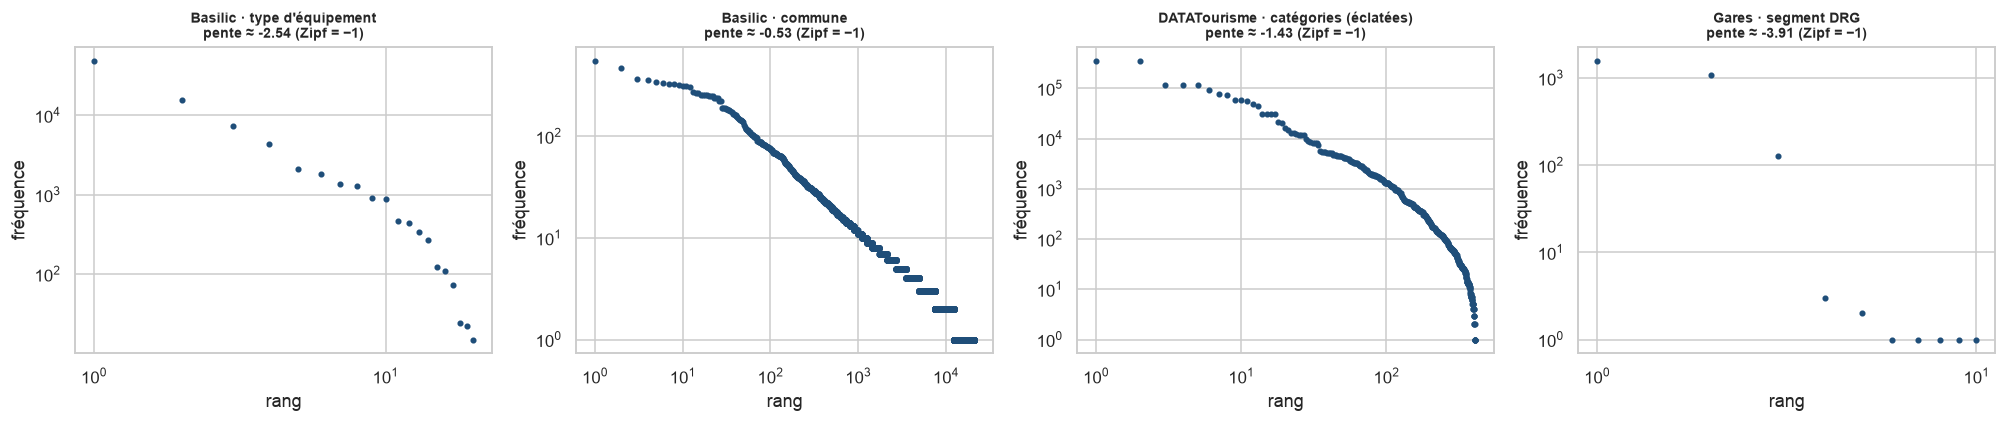

In [72]:
series = {}
if (b := find("basilic")) is not None:
    series["Basilic · type d'équipement"] = b["Type équipement ou lieu"].dropna() if "Type équipement ou lieu" in b else None
    series["Basilic · commune"] = b["libelle_geographique"].dropna() if "libelle_geographique" in b else None
if (dtm := find("datatourisme_place")) is not None and "Categories_de_POI" in dtm:
    series["DATATourisme · catégories (éclatées)"] = dtm.Categories_de_POI.dropna().str.split("|").explode().str.split("#").str[-1]
if (g := find("gares_voyageurs")) is not None and "Segment(s) DRG" in g:
    series["Gares · segment DRG"] = g["Segment(s) DRG"].dropna()
series = {k: v for k, v in series.items() if v is not None}

fig, axes = plt.subplots(1, len(series), figsize=(4.6 * len(series), 4), squeeze=False)
for ax, (name, s) in zip(axes[0], series.items()):
    f = s.value_counts().values
    r = np.arange(1, len(f) + 1)
    top = min(len(f), 100)
    slope = np.polyfit(np.log(r[:top]), np.log(f[:top]), 1)[0]
    ax.loglog(r, f, ".", color="#1f4e79"); ax.set_title(f"{name}\npente ≈ {slope:.2f} (Zipf = −1)", fontsize=9)
    ax.set_xlabel("rang"); ax.set_ylabel("fréquence")
plt.tight_layout(); plt.show()

### 10.7 Poésie des noms de gares
Longueurs, mots les plus fréquents, effet « Saint-… », lettres initiales. Un détour sans objectif, mais un bon test de
**normalisation de noms** (indispensable pour rapprocher gares, arrêts GTFS et POI).

Mots les plus fréquents : [('saint', 293), ('sur', 219), ('les', 124), ('pont', 35), ('sainte', 24), ('seine', 22), ('mer', 22), ('bains', 21), ('loire', 19), ('tgv', 15), ('pierre', 14), ('bois', 13), ('chateau', 13), ('ville', 12), ('mont', 12)]
Gares en « Saint-… » : 7.9% · avec un tiret : 42%
Plus longs noms : ['La Plaine Stade de France - Saint-Denis - Aubervilliers', 'Pont du Garigliano - Hôpital Européen Georges Pompidou', 'Saint-Quentin en Yvelines - Montigny-le-Bretonneux']
Plus courts     : ['Eu', 'Us', 'Ay', 'Ors', 'Dax']
Noms de gare en doublon (après normalisation) : 0 → {}


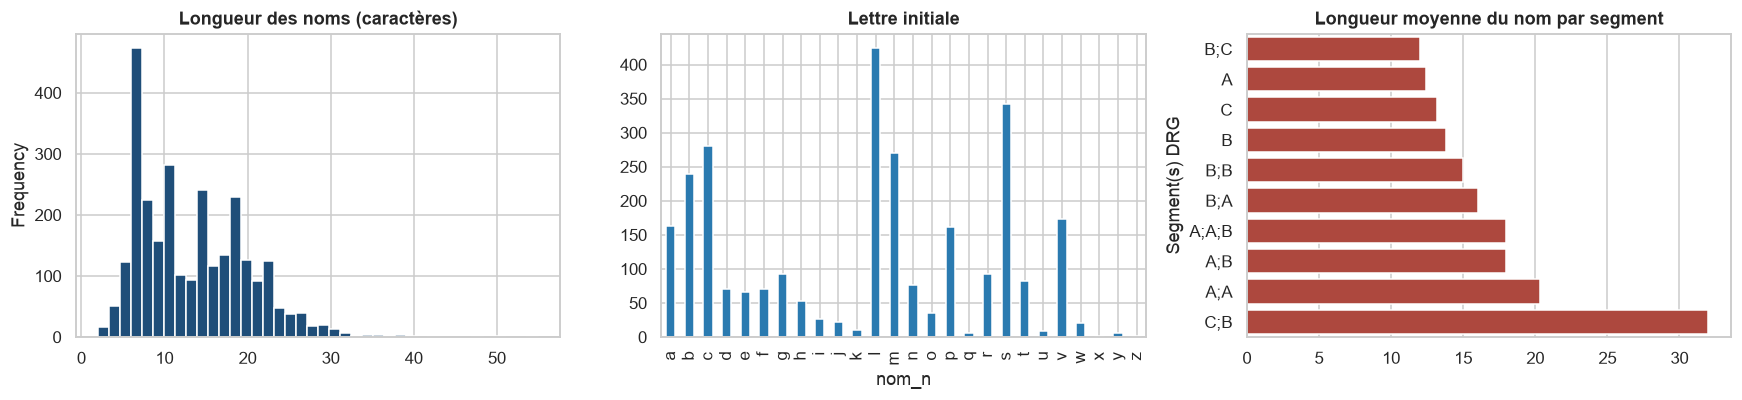


Rapprochement par nom normalisé gares ↔ arrêts GTFS : 79% de couverture
Exemples sans correspondance : ['Ablon-sur-Seine', 'Achères Grand Cormier', 'Achères Ville', 'Achiet-le-Grand', 'Aéroport Charles de Gaulle 1', 'Albi', 'Allée de la Tour Rendez-Vous', 'Allée Royale']


In [73]:
if not absent("gares_voyageurs"):
    g = find("gares_voyageurs").copy()
    g["nom_n"] = g.Nom_Gare.map(norm)
    words = Counter(w for n in g.nom_n for w in n.split() if len(w) > 2)
    print("Mots les plus fréquents :", words.most_common(15))
    print(f"Gares en « Saint-… » : {100 * g.nom_n.str.startswith('saint').mean():.1f}% · avec un tiret : {100 * g.Nom_Gare.str.contains('-').mean():.0f}%")
    print("Plus longs noms :", list(g.Nom_Gare.loc[g.Nom_Gare.str.len().sort_values(ascending=False).index[:3]]))
    print("Plus courts     :", list(g.Nom_Gare.loc[g.Nom_Gare.str.len().sort_values().index[:5]]))
    dup = g.nom_n.value_counts(); dup = dup[dup > 1]
    print(f"Noms de gare en doublon (après normalisation) : {len(dup)} →", dict(dup.head(6)))

    fig, axes = plt.subplots(1, 3, figsize=(16, 3.8))
    g.Nom_Gare.str.len().plot(kind="hist", bins=40, ax=axes[0], color="#1f4e79"); axes[0].set_title("Longueur des noms (caractères)")
    g.nom_n.str[0].value_counts().sort_index().plot(kind="bar", ax=axes[1], color="#2a7ab0"); axes[1].set_title("Lettre initiale")
    if "Segment(s) DRG" in g:
        seg = g.groupby("Segment(s) DRG").Nom_Gare.apply(lambda s: s.str.len().mean()).sort_values()
        sns.barplot(x=seg.values, y=seg.index, ax=axes[2], color="#c0392b"); axes[2].set_title("Longueur moyenne du nom par segment")
    plt.tight_layout(); plt.show()

    # Test de rapprochement exact, gares voyageurs ↔ arrêts GTFS (qualité du matching par nom)
    if (stops := find("gtfs/stops")) is not None:
        sn = set(stops.stop_name.map(norm))
        hit = g.nom_n.isin(sn)
        print(f"\nRapprochement par nom normalisé gares ↔ arrêts GTFS : {100 * hit.mean():.0f}% de couverture")
        print("Exemples sans correspondance :", list(g.Nom_Gare[~hit].head(8)))

### 10.8 Portrait-robot des départements (PCA + clustering)
*Idée :* résumer chaque département par son **profil culturel** (parts par domaine), son volume, son nombre de gares et ses POI
touristiques, puis laisser une ACP + K-means dessiner des familles. On cherche surtout les départements « atypiques » :
beaucoup de culture, peu de gares.

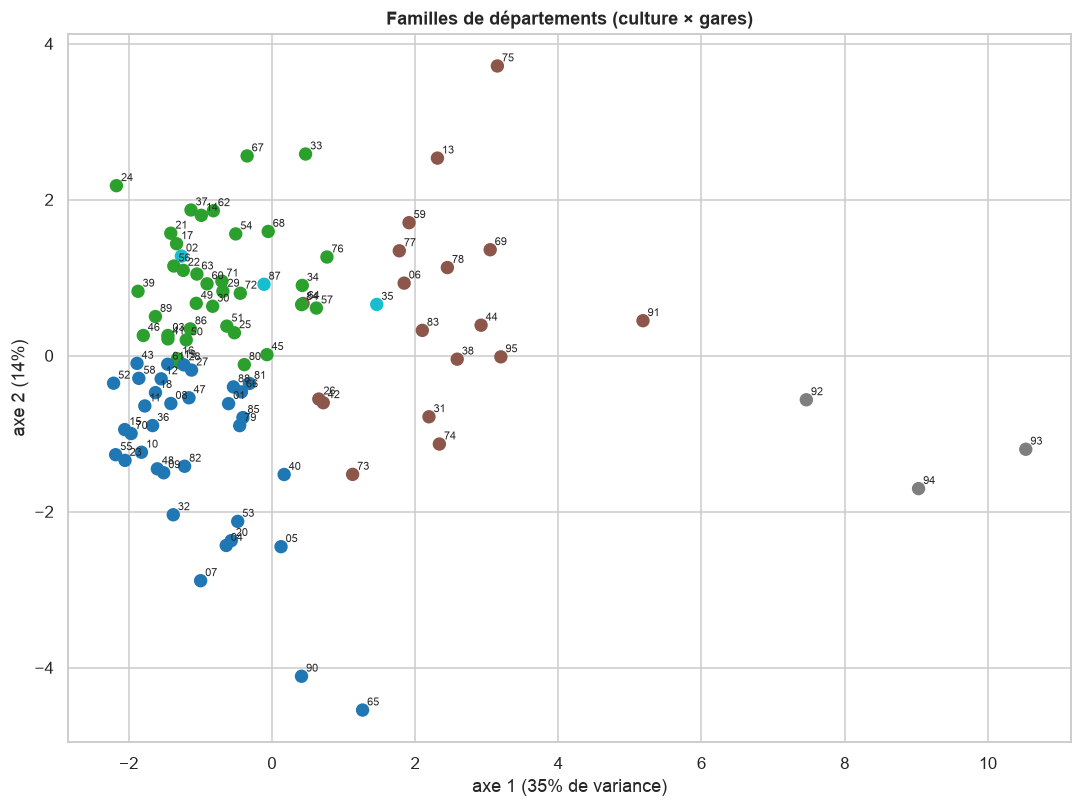

Ce que mesurent les axes :


,axe1,axe2
part_Arts du spectacle,0.42,0.05
part_Archives,0.41,-0.04
part_Éducation et formation,0.41,-0.01
part_Livre et presse,0.39,0.08
part_Patrimoine,-0.38,0.16
part_Cinéma,0.34,-0.20
log_gares,0.16,0.49
part_Arts visuels,0.14,-0.02



Départements avec le plus de sites culturels par gare (ferroviairement sous-équipés) :


,gares,culture_par_gare,famille
dep,,,
07,1.0,679.0,0
75,28.0,134.5,2
32,4.0,133.2,0
10,5.0,125.6,0
04,4.0,102.0,0
70,7.0,84.6,0
50,10.0,81.4,1
56,19.0,78.3,1
16,9.0,76.0,1


In [74]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

def dept_from_insee(code):
    s = str(code).strip().zfill(5)
    return s[:3] if s.startswith(("97", "98")) else ("20" if s[:2] in {"2A", "2B"} else s[:2])

feat = None
if find("basilic") is not None and find("gares_voyageurs") is not None:
    b = find("basilic").copy()
    b["dep"] = b["N_Département"].astype(str).str.replace(r"\.0$", "", regex=True).str.zfill(2).replace({"2A": "20", "2B": "20"})
    cult = b.pivot_table(index="dep", columns="Domaine", values="Nom", aggfunc="size", fill_value=0)
    total = cult.sum(axis=1)
    share = cult.div(total, axis=0).add_prefix("part_")
    g = find("gares_voyageurs").copy()
    gares_dep = g["Code commune"].map(dept_from_insee).value_counts().rename("gares")
    feat = share.assign(log_culture=np.log1p(total)).join(gares_dep).fillna({"gares": 0})
    feat["log_gares"] = np.log1p(feat.gares)
    feat["culture_par_gare"] = total / feat.gares.replace(0, np.nan)
    if (dtm := find("datatourisme_place")) is not None and "Code_postal_et_commune" in dtm:
        dp = dtm.Code_postal_et_commune.astype(str).str.extract(r"(\d{5})")[0].dropna().map(dept_from_insee).value_counts()
        feat = feat.join(np.log1p(dp).rename("log_datatourisme")).fillna({"log_datatourisme": 0})
    feat = feat[feat.index.str.match(r"^\d{2}$")]            # métropole : l'outre-mer (sans gares dans la source) écrase les axes
    X = feat.drop(columns=["gares", "culture_par_gare"]).fillna(0)
    Z = StandardScaler().fit_transform(X)
    pca = PCA(n_components=2, random_state=SEED).fit(Z)
    P = pca.transform(Z)
    km = KMeans(n_clusters=5, n_init=10, random_state=SEED).fit(Z)
    fig, ax = plt.subplots(figsize=(10, 7.5))
    sc = ax.scatter(P[:, 0], P[:, 1], c=km.labels_, cmap="tab10", s=60)
    for i, dep in enumerate(feat.index):
        ax.annotate(dep, (P[i, 0], P[i, 1]), fontsize=7, xytext=(3, 3), textcoords="offset points")
    ax.set_xlabel(f"axe 1 ({100 * pca.explained_variance_ratio_[0]:.0f}% de variance)")
    ax.set_ylabel(f"axe 2 ({100 * pca.explained_variance_ratio_[1]:.0f}%)"); ax.set_title("Familles de départements (culture × gares)")
    plt.tight_layout(); plt.show()
    load = pd.DataFrame(pca.components_.T, index=X.columns, columns=["axe1", "axe2"]).round(2)
    print("Ce que mesurent les axes :"); display(load.reindex(load.axe1.abs().sort_values(ascending=False).index).head(8))
    feat["famille"] = km.labels_
    print("\nDépartements avec le plus de sites culturels par gare (ferroviairement sous-équipés) :")
    display(feat.sort_values("culture_par_gare", ascending=False)[["gares", "culture_par_gare", "famille"]].head(10).round(1))
else:
    print("Nécessite basilic + gares_voyageurs.")

### 10.9 Doublons « jumeaux » : les noms qui se répètent à des endroits différents
*Idée :* « Église Saint-Pierre » existe partout. Un nom très répété à des coordonnées différentes n'est **pas** un doublon,
alors qu'un nom répété à la **même** coordonnée en est un. La distinction conditionne toute règle de déduplication future.

In [75]:
for frag, namecol, geo in [("basilic", "Nom", "basilic"), ("datatourisme_place", "Nom_du_POI", "datatourisme")]:
    df = find(frag)
    if df is None or geo not in GEO or namecol not in df:
        continue
    d = df[[namecol]].assign(nn=df[namecol].map(norm)).join(GEO[geo][["lat", "lon"]])
    top = d.groupby("nn").agg(occurrences=("nn", "size"), lieux_distincts=("lat", lambda s: s.round(3).nunique())).query("occurrences > 5")
    top["vrais_doublons_potentiels"] = top.occurrences - top.lieux_distincts
    print(f"\n{frag} — noms les plus répétés :")
    display(top.sort_values("occurrences", ascending=False).head(10))
    full = d.dropna(subset=["lat", "lon"]).duplicated(["nn", "lat", "lon"], keep=False).mean()
    print(f"Lignes dont (nom, coordonnée) est dupliqué : {100 * full:.2f}%")


basilic — noms les plus répétés :


,occurrences,lieux_distincts,vrais_doublons_potentiels
nn,,,
maison,2952,973,1979
eglise,2537,1914,623
immeuble,2322,600,1722
bibliotheque municipale,2134,1839,295
chateau,1197,1094,103
eglise saint martin,492,467,25
mediatheque municipale,478,458,20
bibliotheque,458,424,34
eglise saint pierre,413,402,11


Lignes dont (nom, coordonnée) est dupliqué : 1.83%

datatourisme_place — noms les plus répétés :


,occurrences,lieux_distincts,vrais_doublons_potentiels
nn,,,
aire de pique nique,825,718,107
aire de jeux,351,310,41
eglise saint martin,332,319,13
toilettes publiques,313,209,104
eglise saint pierre,249,241,8
bibliotheque,238,228,10
bibliotheque municipale,222,216,6
meuble de tourisme,170,135,35
la grange,169,161,8


Lignes dont (nom, coordonnée) est dupliqué : 2.20%


---
# 11. Conclusion graphique — trois relations et un indicateur

Après tout ce qui précède, on garde **ce qui sert l'objectif** : recommander un trajet en train vers un lieu culturel ou un événement,
puis le dernier kilomètre. Trois graphiques, chacun relie deux informations qui, seules, ne disent rien :

| Graphique | Relation | Ce qu'il apprend |
|---|---|---|
| **A** | type de site × distance à la gare | Combien de sites sont accessibles à pied, avec un dernier km, ou hors de portée |
| **B** | richesse culturelle autour d'une gare × places TGVmax ouvertes | Où aller : beaucoup à voir **et** des places |
| **C** | volume de sites × score d'accessibilité, par département | Où le train ne suffit pas, donc où le vélo, le bus et l'autopartage sont indispensables |

**Indicateur : l'Indice d'Accessibilité Ferroviaire (IAF, 0-100)** = moyenne pondérée des sites selon leur distance à la gare la plus proche
(à vol d'oiseau, donc optimiste) : ≤ 1 km = 1, 1-5 km = 0,5, 5-25 km = 0,1, au-delà = 0. Les poids sont une **hypothèse de travail**
(modifiables dans `POIDS_TRANCHES`) : ils disent « à pied, c'est gagné ; avec un vélo ou un bus, c'est jouable ; au-delà, il faut une voiture ».

In [76]:
# ── Préparation : un tableau unique « sites » (culture + tourisme + événements à venir) ──────────────
POIDS_TRANCHES = {"≤ 1 km": 1.0, "1-5 km": 0.5, "5-25 km": 0.1, "> 25 km": 0.0}   # hypothèse à discuter
BINS = [-np.inf, 1, 5, 25, np.inf]
LABELS = list(POIDS_TRANCHES)
COULEURS_TRANCHES = ["#2e8b57", "#9acd32", "#f0a030", "#c0392b"]


def dep_from_postal(s):
    return s.astype(str).str.extract(r"(\d{5})")[0].str[:2]


def sites_part(label, name, dep):
    km = DIST[name]
    return pd.DataFrame({"source": label, "km": km, "dep": dep.reindex(km.index),
                         "lat": GEO[name].lat.reindex(km.index), "lon": GEO[name].lon.reindex(km.index)})


parts = []
if "DIST" in globals():
    if "basilic" in DIST and (b := find("basilic")) is not None:
        dep_b = b["N_Département"].astype(str).str.replace(r"\.0$", "", regex=True).str.zfill(2)
        parts.append(sites_part("Culture (Basilic)", "basilic", dep_b))
    if "datatourisme" in DIST and (dtm := find("datatourisme_place")) is not None:
        parts.append(sites_part("Tourisme (DATATourisme)", "datatourisme", dep_from_postal(dtm.Code_postal_et_commune)))
    if "événements" in DIST and "EVENTS_ACTIFS" in globals():
        fma = find("datatourisme_fma")
        p = sites_part("Événements à venir (fin 2026)", "événements", dep_from_postal(fma.Code_postal_et_commune))
        parts.append(p.loc[p.index.intersection(EVENTS_ACTIFS.index)])

POIS = None
if not parts:
    print("⚠ Conclusion impossible : il faut gares_voyageurs + basilic / datatourisme_place / datatourisme_fma dans SOURCES.")
else:
    POIS = pd.concat(parts, ignore_index=True)
    POIS["tranche"] = pd.cut(POIS.km, BINS, labels=LABELS)
    POIS["w"] = POIS.tranche.map(POIDS_TRANCHES).astype(float)
    print(f"{len(POIS):,} sites analysés (Corse et outre-mer exclus).".replace(",", " "))

489 630 sites analysés (Corse et outre-mer exclus).


### Graphique A — Type de site × distance à la gare

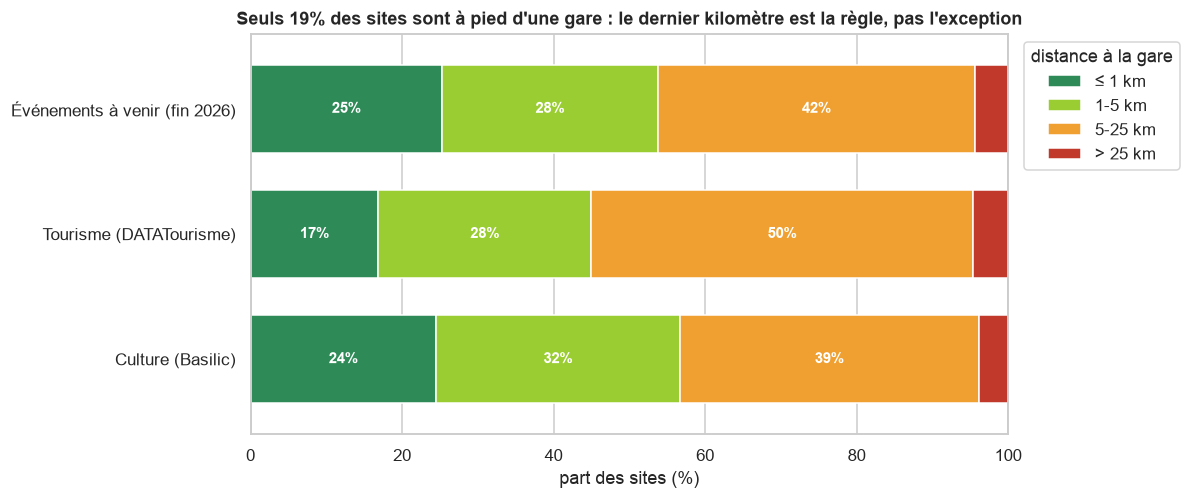

In [77]:
if POIS is not None:
    share = (POIS.groupby("source").tranche.value_counts(normalize=True).unstack().reindex(columns=LABELS) * 100)
    fig, ax = plt.subplots(figsize=(11, 3.2 + 0.5 * len(share)))
    share.plot.barh(stacked=True, ax=ax, color=COULEURS_TRANCHES, width=.7)
    for i, (src, row) in enumerate(share.iterrows()):
        x = 0
        for lab in LABELS:
            if row[lab] >= 6:
                ax.text(x + row[lab] / 2, i, f"{row[lab]:.0f}%", ha="center", va="center", color="white", fontsize=10, fontweight="bold")
            x += row[lab]
    ax.set_xlim(0, 100); ax.set_xlabel("part des sites (%)"); ax.set_ylabel("")
    ax.legend(title="distance à la gare", bbox_to_anchor=(1.01, 1), loc="upper left")
    marche = POIS.km.le(1).mean() * 100
    ax.set_title(f"Seuls {marche:.0f}% des sites sont à pied d'une gare : le dernier kilomètre est la règle, pas l'exception")
    plt.tight_layout(); plt.show()

### Graphique B — Où aller ? Richesse culturelle × places TGVmax
Chaque point est une gare d'arrivée TGVmax. En abscisse, le nombre de sites (culture, tourisme, événements à venir) à moins de 5 km ;
en ordonnée, la part des trains arrivant là qui ont des places MAX ouvertes. En haut à droite : **beaucoup à faire et des places**.

Gares d'arrivée TGVmax localisées : 221 (couvrent 82% des trajets, hors gares < 100 trains)
16 gare(s) écartée(s) : aucun site à 5 km, localisation par le nom douteuse.


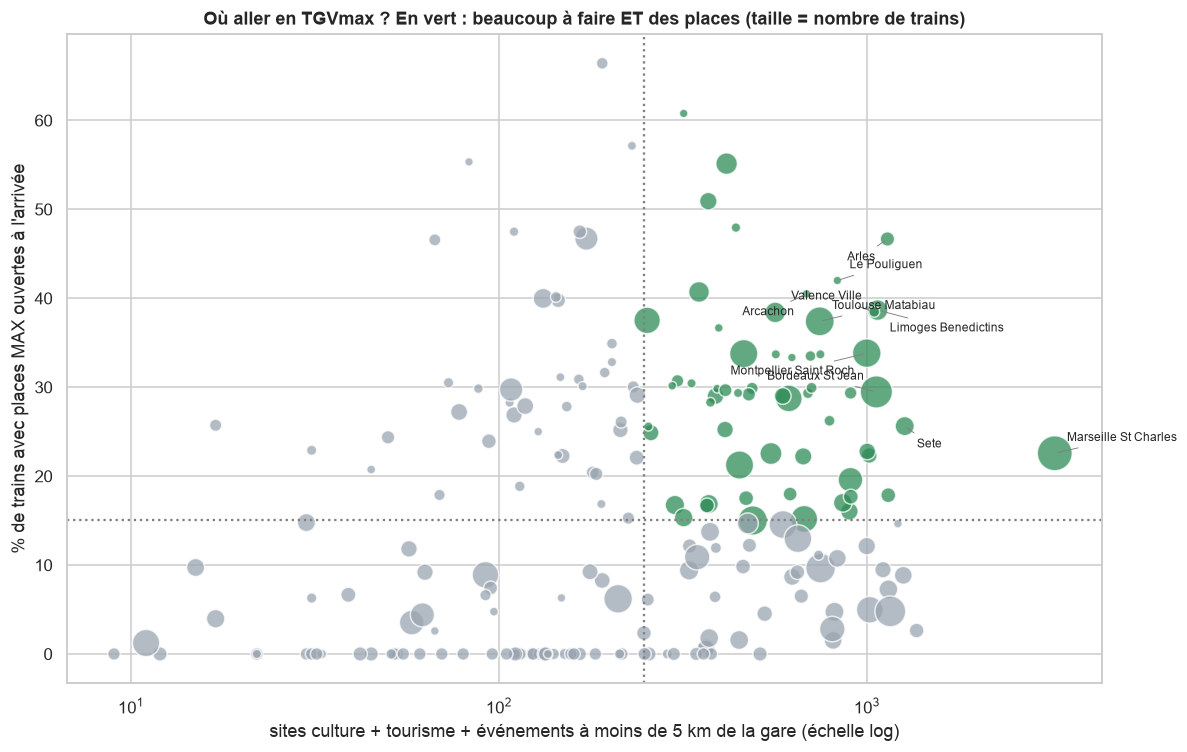

,Destination,trains,sites_5km,pct_ouvert
0,MARSEILLE ST CHARLES,7878,3243,22.6
1,ARLES,1005,1138,46.7
2,LIMOGES BENEDICTINS,2493,1070,38.7
3,VALENCE VILLE,408,1048,38.5
4,LE POULIGUEN,100,832,42.0
5,MONTPELLIER SAINT ROCH,5123,1000,33.8
6,SETE,2092,1268,25.6
7,BORDEAUX ST JEAN,6624,1062,29.5
8,TOULOUSE MATABIAU,5280,745,37.4
9,ARCACHON,121,686,40.5


In [78]:
SWEET = None
if POIS is not None and TGV is not None:
    def st_key(x):
        n = norm(x)
        return re.sub(r"\bste\b", "sainte", re.sub(r"\bst\b", "saint", n))

    # Référentiel nom de gare → coordonnées : gares voyageurs, puis arrêts GTFS « gare mère »
    ref = {}
    def add_ref(names, lats, lons):
        for n, la, lo in zip(names, lats, lons):
            if pd.notna(la) and pd.notna(lo):
                ref.setdefault(st_key(n), (float(la), float(lo)))
    gv = find("gares_voyageurs")
    gg = GEO["gares"].reindex(gv.index)
    add_ref(gv.Nom_Gare, gg.lat, gg.lon)
    stp = find("gtfs/stops")
    if stp is not None:
        sa = stp[stp["location_type"] == 1] if "location_type" in stp else stp
        add_ref(sa.stop_name, sa.stop_lat, sa.stop_lon)
    keys = list(ref)

    def locate(name):
        n = st_key(name).replace(" intramuros", "")
        toks = n.split()
        cands = [n] + ([" ".join(toks[:-1])] if toks and toks[-1] in {"tgv", "ville", "centre", "gare"} else [])
        for c in cands:
            if c in ref:
                return ref[c]
        for c in cands:                                   # « paris », « lyon » : centre des gares dont le nom commence ainsi
            hits = [k for k in keys if k.startswith(c + " ")]
            if 0 < len(hits) <= 8:
                return tuple(np.mean([ref[k] for k in hits], axis=0))
        return None

    dest = TGV.groupby("Destination").agg(trains=("dispo", "size"), ouvertes=("dispo", "mean")).reset_index()
    dest["pos"] = dest.Destination.map(locate)
    cover = dest.dropna(subset=["pos"]).trains.sum() / dest.trains.sum()
    st_ok = dest.dropna(subset=["pos"]).copy()
    st_ok["lat"], st_ok["lon"] = st_ok.pos.str[0], st_ok.pos.str[1]
    st_ok = st_ok[st_ok.lat.between(41, 51.5) & st_ok.lon.between(-5.5, 10) & (st_ok.trains >= 100)]
    print(f"Gares d'arrivée TGVmax localisées : {len(st_ok)} (couvrent {100 * cover:.0f}% des trajets, hors gares < 100 trains)")

    pts = POIS.dropna(subset=["lat", "lon"])
    tree_p = BallTree(np.radians(pts[["lat", "lon"]].values), metric="haversine")
    st_ok["sites_5km"] = tree_p.query_radius(np.radians(st_ok[["lat", "lon"]].values), r=5 / R_TERRE, count_only=True)
    n_vides = int((st_ok.sites_5km == 0).sum())
    st_ok = st_ok[st_ok.sites_5km > 0].copy()                 # 0 site à 5 km = gare mal localisée par son nom (écartée)
    print(f"{n_vides} gare(s) écartée(s) : aucun site à 5 km, localisation par le nom douteuse.")
    st_ok["pct_ouvert"] = st_ok.ouvertes * 100
    mx, my = st_ok.sites_5km.median(), st_ok.pct_ouvert.median()
    st_ok["sweet"] = (st_ok.sites_5km >= mx) & (st_ok.pct_ouvert >= my)
    st_ok["score"] = st_ok.sites_5km * st_ok.pct_ouvert
    SWEET = st_ok.sort_values("score", ascending=False)

    fig, ax = plt.subplots(figsize=(11, 7))
    ax.scatter(st_ok.sites_5km, st_ok.pct_ouvert, s=st_ok.trains / st_ok.trains.max() * 500 + 25,
               c=np.where(st_ok.sweet, "#2e8b57", "#9aa5b1"), alpha=.75, edgecolor="white")
    ax.set_xscale("log"); ax.axvline(mx, color="grey", ls=":"); ax.axhline(my, color="grey", ls=":")
    offsets = [(8, 8), (-8, -14), (8, -14), (-8, 8)]
    for n, (_, r) in enumerate(SWEET[SWEET.sweet].head(10).iterrows()):
        dx, dy = offsets[n % 4]
        ax.annotate(r.Destination.title(), (r.sites_5km, r.pct_ouvert), fontsize=8, xytext=(dx, dy), textcoords="offset points",
                    ha="left" if dx > 0 else "right", arrowprops=dict(arrowstyle="-", color="grey", lw=.6))
    ax.set_xlabel("sites culture + tourisme + événements à moins de 5 km de la gare (échelle log)")
    ax.set_ylabel("% de trains avec places MAX ouvertes à l'arrivée")
    ax.set_title("Où aller en TGVmax ? En vert : beaucoup à faire ET des places (taille = nombre de trains)")
    plt.tight_layout(); plt.show()
    display(SWEET[SWEET.sweet].head(10)[["Destination", "trains", "sites_5km", "pct_ouvert"]].round(1).reset_index(drop=True))
else:
    print("Nécessite POIS et TGVmax.")

### Graphique C — Par département : volume de sites × score d'accessibilité
Les départements en bas à droite ont **beaucoup de sites mais un mauvais score** : c'est là que le train seul ne suffit pas
et que les solutions de dernier kilomètre (vélo, bus, autopartage) ont le plus de valeur.

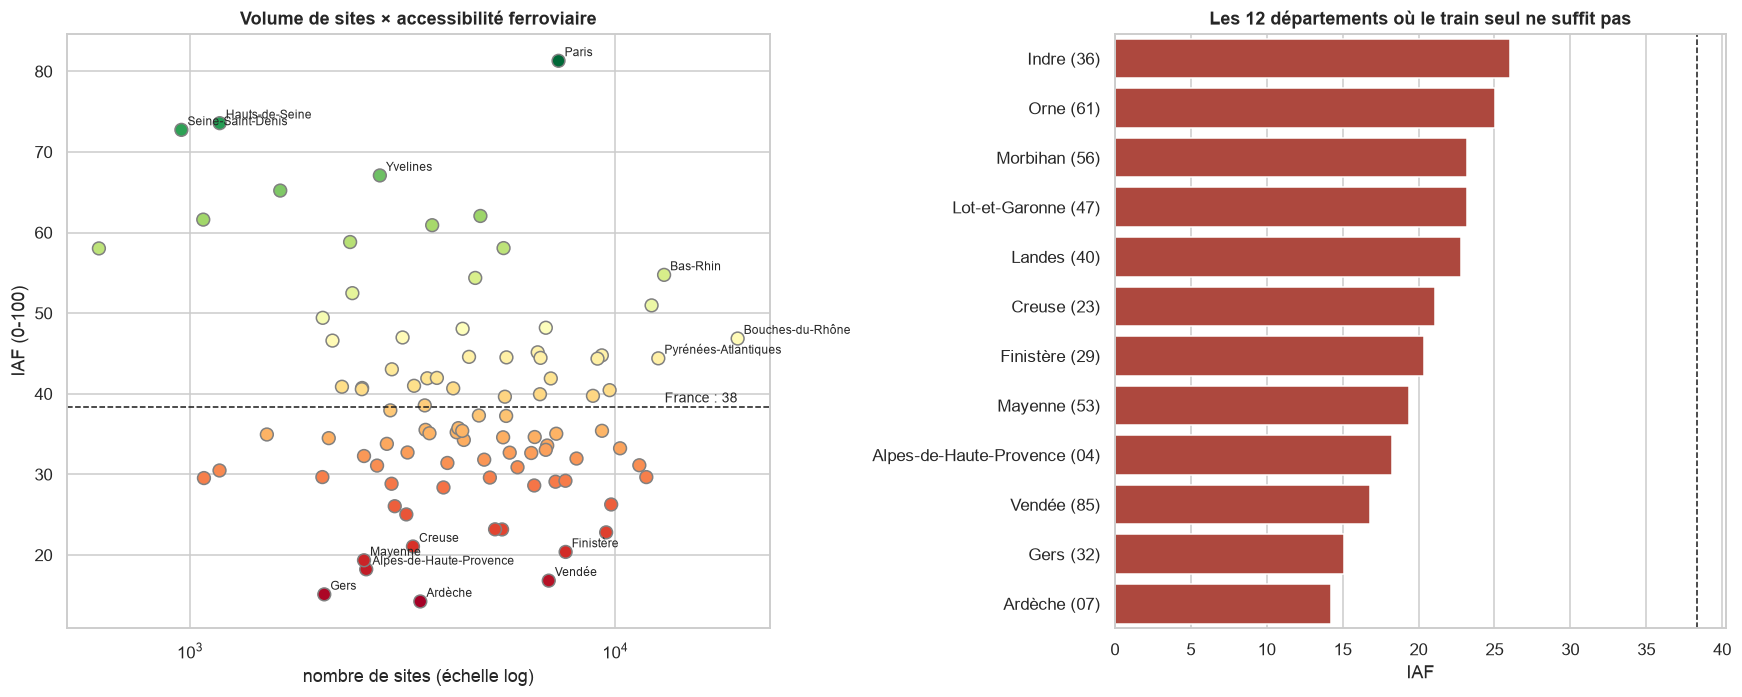

In [79]:
DEPS = None
if POIS is not None:
    nom = {}
    if (b := find("basilic")) is not None and "Département" in b:
        tmp = b[["N_Département", "Département"]].dropna().astype(str)
        tmp["c"] = tmp.N_Département.str.replace(r"\.0$", "", regex=True).str.zfill(2)
        nom = tmp.drop_duplicates("c").set_index("c").Département.to_dict()
    DEPS = (POIS.dropna(subset=["dep"]).groupby("dep")
            .agg(sites=("km", "size"), IAF=("w", lambda w: 100 * w.mean()), pct_5km=("km", lambda k: 100 * (k <= 5).mean()))
            .query("sites >= 300"))
    DEPS["nom"] = [f"{nom.get(d, d)} ({d})" for d in DEPS.index]
    iaf_nat = 100 * POIS.w.mean()

    fig, axes = plt.subplots(1, 2, figsize=(16, 6.5), gridspec_kw={"width_ratios": [1.15, 1]})
    ax = axes[0]
    sc = ax.scatter(DEPS.sites, DEPS.IAF, c=DEPS.IAF, cmap="RdYlGn", s=70, edgecolor="grey", vmin=DEPS.IAF.min(), vmax=DEPS.IAF.max())
    ax.set_xscale("log"); ax.axhline(iaf_nat, color="k", ls="--", lw=1); ax.text(DEPS.sites.max(), iaf_nat + .6, f"France : {iaf_nat:.0f}", ha="right", fontsize=9)
    for d, r in pd.concat([DEPS.nsmallest(7, "IAF"), DEPS.nlargest(4, "IAF"), DEPS.nlargest(3, "sites")]).drop_duplicates().iterrows():
        ax.annotate(r.nom.split(" (")[0], (r.sites, r.IAF), fontsize=8, xytext=(4, 3), textcoords="offset points")
    ax.set_xlabel("nombre de sites (échelle log)"); ax.set_ylabel("IAF (0-100)"); ax.set_title("Volume de sites × accessibilité ferroviaire")
    ax = axes[1]
    worst = DEPS.nsmallest(12, "IAF").sort_values("IAF", ascending=False)
    sns.barplot(x=worst.IAF, y=worst.nom, ax=ax, color="#c0392b"); ax.axvline(iaf_nat, color="k", ls="--", lw=1)
    ax.set_xlabel("IAF"); ax.set_ylabel(""); ax.set_title("Les 12 départements où le train seul ne suffit pas")
    plt.tight_layout(); plt.show()

### Indicateur global et lecture

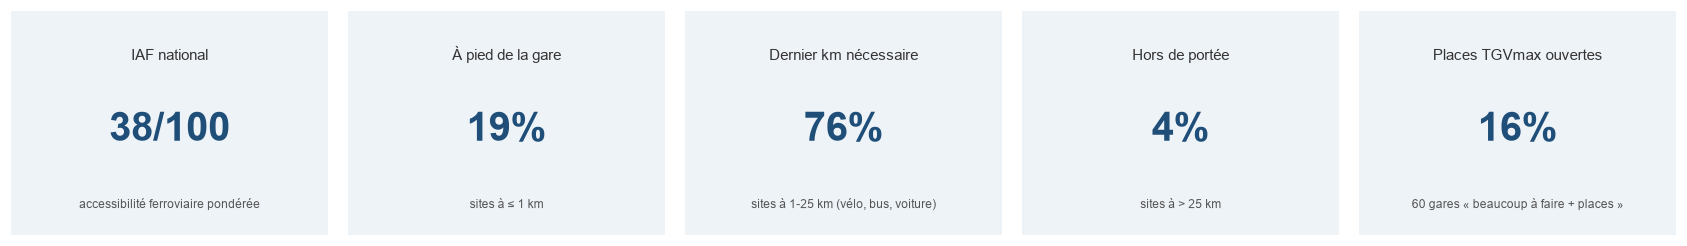

Lecture : sur 489 630 sites, 19% sont à pied d'une gare et 76% demandent un dernier kilomètre ; l'IAF national est de 38/100.
Les départements les moins bien servis (≥ 300 sites) : Ardèche (07), Gers (32), Vendée (85).
→ Le service à construire n'est pas « un meilleur train » mais « le train + le dernier kilomètre » : les sources à ajouter en priorité sont donc les GTFS locaux, le vélo en libre-service et le stationnement vélo.


In [80]:
if POIS is not None:
    iaf = 100 * POIS.w.mean()
    p1 = 100 * POIS.km.le(1).mean()
    p_dernier = 100 * POIS.km.between(1, 25, inclusive="right").mean()
    p_loin = 100 * POIS.km.gt(25).mean()
    tgv_open = 100 * TGV.dispo.mean() if TGV is not None else np.nan
    n_sweet = int(SWEET.sweet.sum()) if SWEET is not None else 0

    tuiles = [("IAF national", f"{iaf:.0f}/100", "accessibilité ferroviaire pondérée"),
              ("À pied de la gare", f"{p1:.0f}%", "sites à ≤ 1 km"),
              ("Dernier km nécessaire", f"{p_dernier:.0f}%", "sites à 1-25 km (vélo, bus, voiture)"),
              ("Hors de portée", f"{p_loin:.0f}%", "sites à > 25 km"),
              ("Places TGVmax ouvertes", f"{tgv_open:.0f}%", f"{n_sweet} gares « beaucoup à faire + places »")]
    fig, axes = plt.subplots(1, len(tuiles), figsize=(3.1 * len(tuiles), 2.4))
    for ax, (titre, val, sous) in zip(axes, tuiles):
        ax.axis("off"); ax.add_patch(plt.Rectangle((0, 0), 1, 1, transform=ax.transAxes, color="#eef3f8", zorder=0))
        ax.text(.5, .78, titre, ha="center", fontsize=10, color="#333", transform=ax.transAxes)
        ax.text(.5, .42, val, ha="center", fontsize=26, fontweight="bold", color="#1f4e79", transform=ax.transAxes)
        ax.text(.5, .12, sous, ha="center", fontsize=8, color="#555", transform=ax.transAxes, wrap=True)
    plt.tight_layout(); plt.show()

    pire = DEPS.nsmallest(3, "IAF").nom.tolist()
    n_sites = f"{len(POIS):,}".replace(",", " ")
    print(f"Lecture : sur {n_sites} sites, {p1:.0f}% sont à pied d'une gare et {p_dernier:.0f}% demandent un dernier kilomètre ; "
          f"l'IAF national est de {iaf:.0f}/100.")
    print(f"Les départements les moins bien servis (≥ 300 sites) : {', '.join(pire)}.")
    print("→ Le service à construire n'est pas « un meilleur train » mais « le train + le dernier kilomètre » : "
          "les sources à ajouter en priorité sont donc les GTFS locaux, le vélo en libre-service et le stationnement vélo.")

---
## Synthèse & pistes

Les constats chiffrés se lisent dans les sorties ci-dessus. À reporter ici une fois le notebook exécuté :

- **Qualité** : sources les plus vides, colonnes constantes, coordonnées hors France, précision de géocodage.
- **Jointures** : clés de jointure confirmées par le radar (10.3), transformations nécessaires (zéros de tête, codes postaux, `[lon,lat]`).
- **Tourisme × gare** : part des sites à plus de 10 / 25 km d'une gare, départements les plus concernés.
- **TGVmax** : créneaux et axes où la disponibilité est la plus élevée.
- **Décisions de modélisation** : colonnes à exclure, regroupements de catégories (Zipf), règles de déduplication.

*Pour élargir :* `SOURCES = [s for s in ALL_SOURCES if s not in HEAVY]` charge tous les GTFS urbains (comparaison de réseaux possible
avec les mêmes helpers).